In [2]:
import matplotlib.pyplot as plt
import numpy as np
import random 
import seaborn as sns
import string
import sys 
import torch

import analysis_utils as au
from analysis_utils import (
    plot_hidden_states,
    plot_averaged_attention,
    plot_headwise_attention
)
from extractor import Extractor

sys.path.append("../")

from checkpoint import CheckPoint
from datasets import LetterStringDataLoader
import evaluate
from generate_data import ALL_TRANSFORMATIONS

BATCH_SIZE = 20
%config InlineBackend.figure_format = 'retina'

### Preliminaries (load model, register extractor)

In [1]:
# load checkpoints:
copy_rand_perm20 = CheckPoint.from_pt("../models/copy_batching_experiments/MLC_batchrand_dallstudy1_copy_perm20_nep20.pt")
rand_perm20 = CheckPoint.from_pt("../models/batching_experiments/MLC_batchrand_dallstudy1_nep20.pt")
alph_perm200 = CheckPoint.from_pt("../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm200_nep20.pt")

# load models and dataset:
model_copy = copy_rand_perm20.load_model(verbose=False)
model_unstruct = rand_perm20.load_model(verbose=False)
model_best = alph_perm200.load_model()
dataloader = LetterStringDataLoader(
    mode="val", 
    data_dir="../data/letter-string-analogies/all_transformations_study1_copy_perm40", 
    batch_size=BATCH_SIZE, 
    batching_method="alphabet"
)

NameError: name 'CheckPoint' is not defined

In [4]:
model_best.transformer.encoder.norm

LayerNorm((128,), eps=1e-05, elementwise_affine=True)

In [5]:
print("Validation Accs by transformation:")
print("-" * 60)
for key, val in alph_perm200.val_acc_hist[-1].items():
    print(f"{key}: {val:.3f}")

Validation Accs by transformation:
------------------------------------------------------------
epoch: 19.000
overall: 0.698
copy: 0.738
noncopy: 0.657
extend_extend_succ: 0.000
extend_group: 0.164
extend_pred: 0.993
extend_sequence: 1.000
fix_alphabetic_seq: 1.000
fix_extend: 0.999
fix_interleave: 0.598
fix_pred_succ: 0.000
pred: 1.000
remove_redundant: 1.000
replicate: 0.000
reverse: 0.000
rr_interleave: 1.000
rr_sort: 0.635
rr_succ: 1.000
shift: 0.000
sort: 1.000
sort_group: 1.000
succ: 1.000
in: 1.000
out-of: 0.271


In [6]:
extractor = Extractor(model_best)
extractor.register()

### Averaged Attention & Hidden States

------------------------------------------------------------
Analysing transformation 'extend_sequence'
------------------------------------------------------------
Task:
a b c d e f g h i j k l m n o p q r s t u v w x y z | i j k l m > i j k l m n | u v w > u v w x



c:\Users\13579681\AppData\Local\anaconda3\envs\mlc-ls\Lib\site-packages\torch\nn\modules\transformer.py:505: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


------------------------------------------------------------
Analysing transformation 'pred'
------------------------------------------------------------
Task:
a b c d e f g h i j k l m n o p q r s t u v w x y z | f g h i j > e g h i j | p q r > o q r

------------------------------------------------------------
Analysing transformation 'extend_pred'
------------------------------------------------------------
Task:
a b c d e f g h i j k l m n o p q r s t u v w x y z | b c d e > a c d e f | o p q r > n p q r s



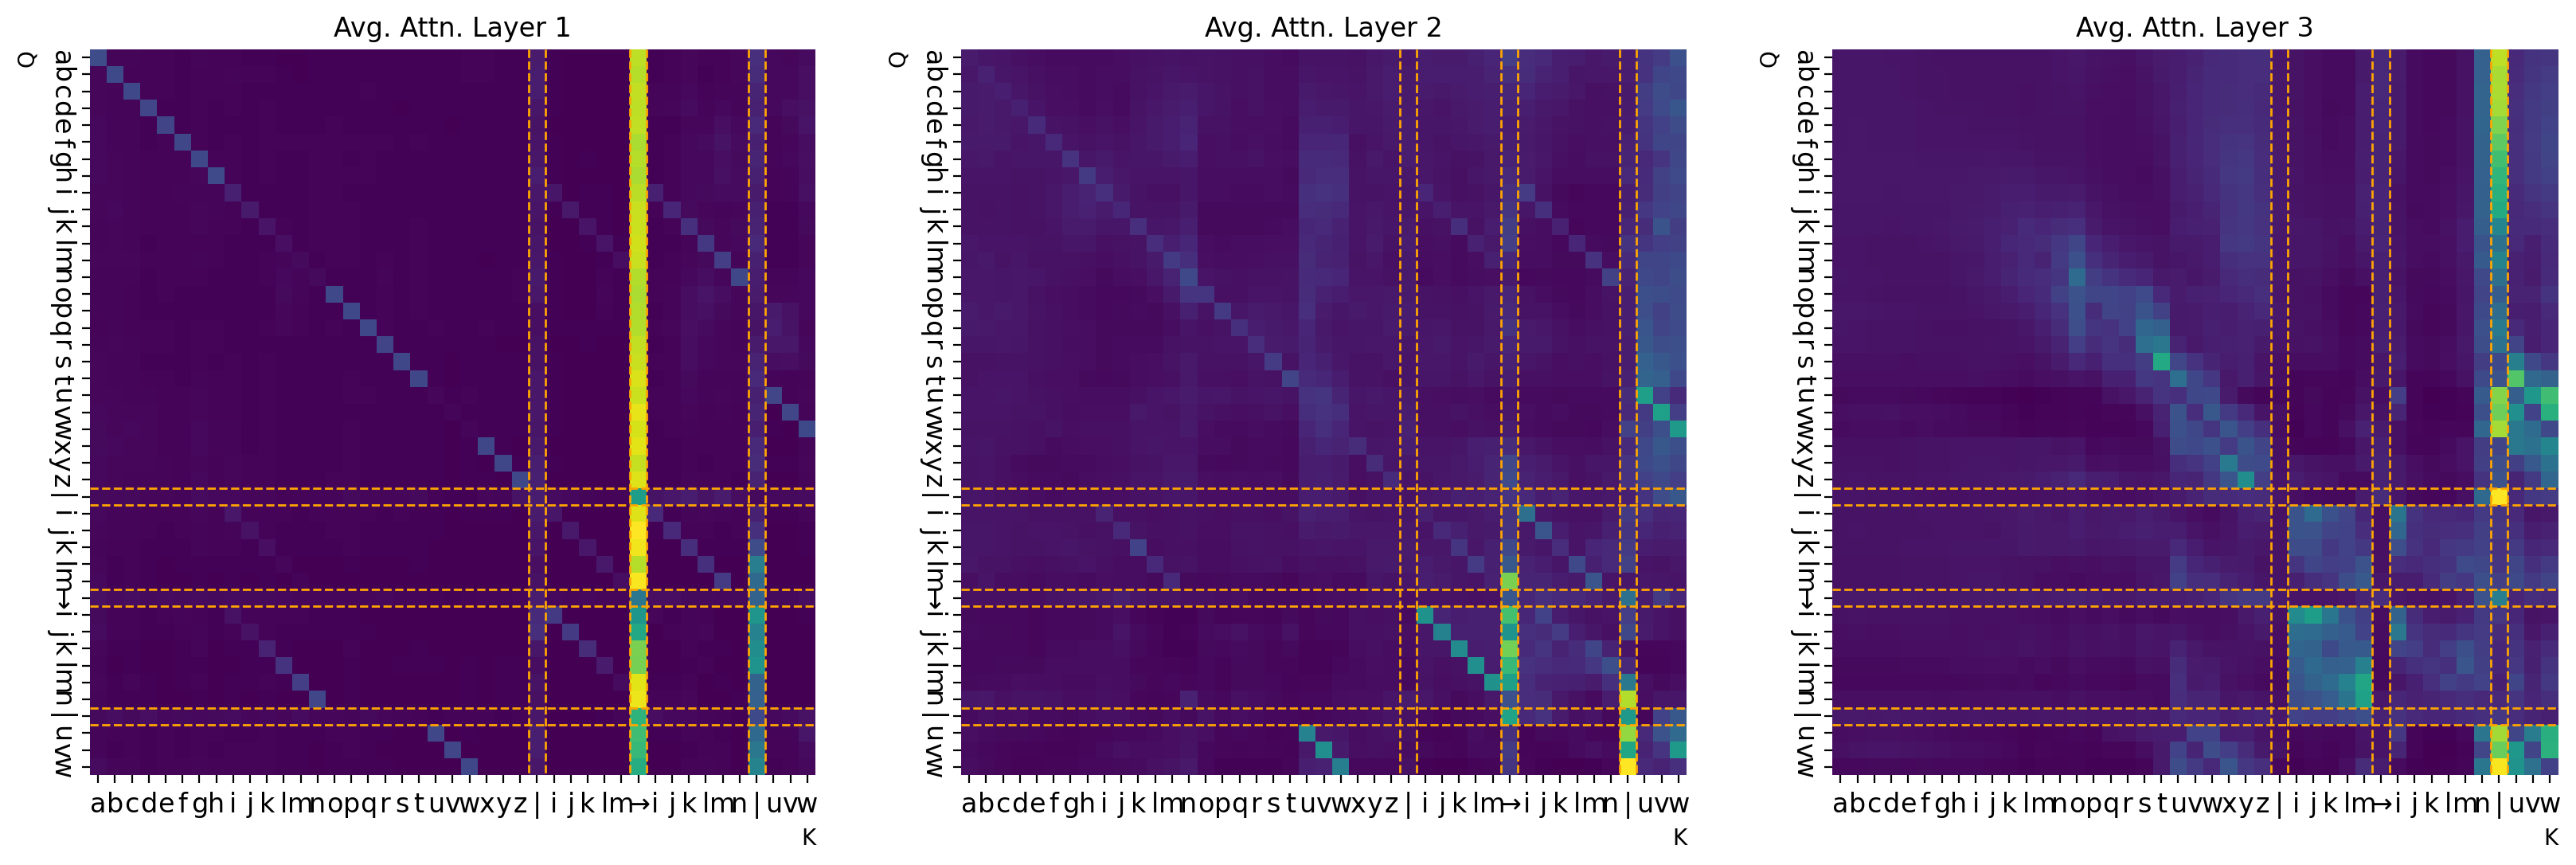

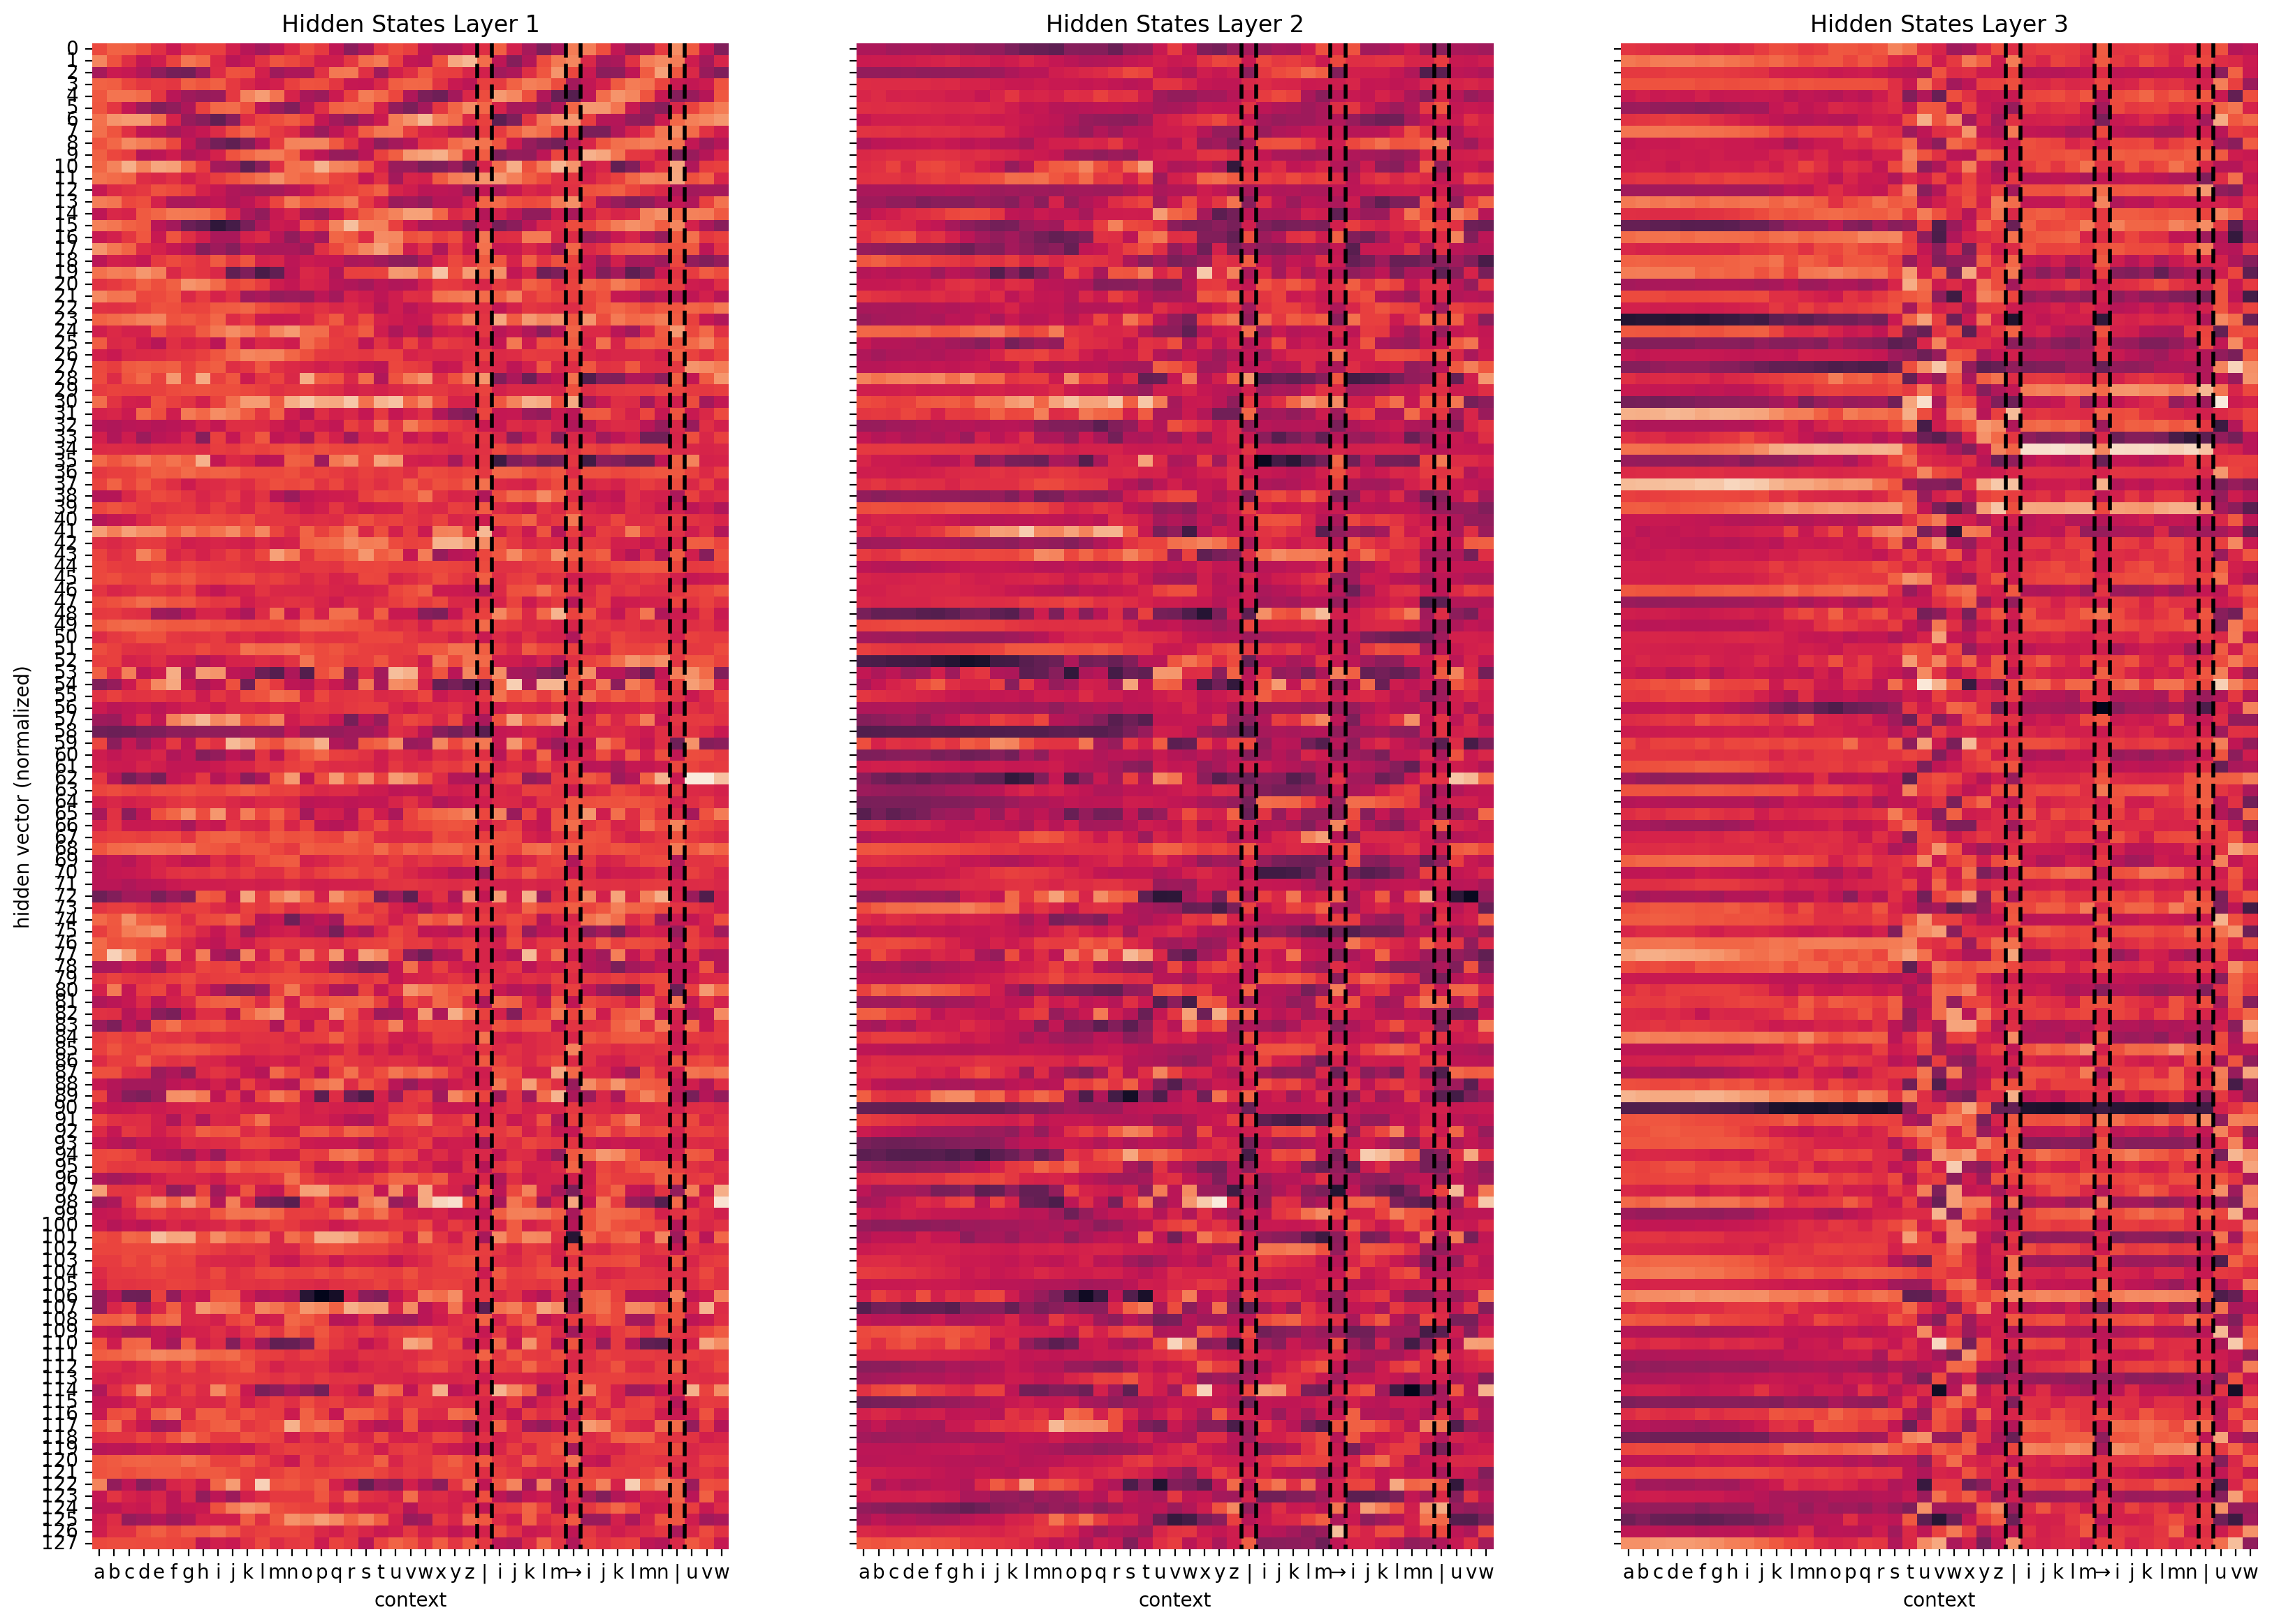

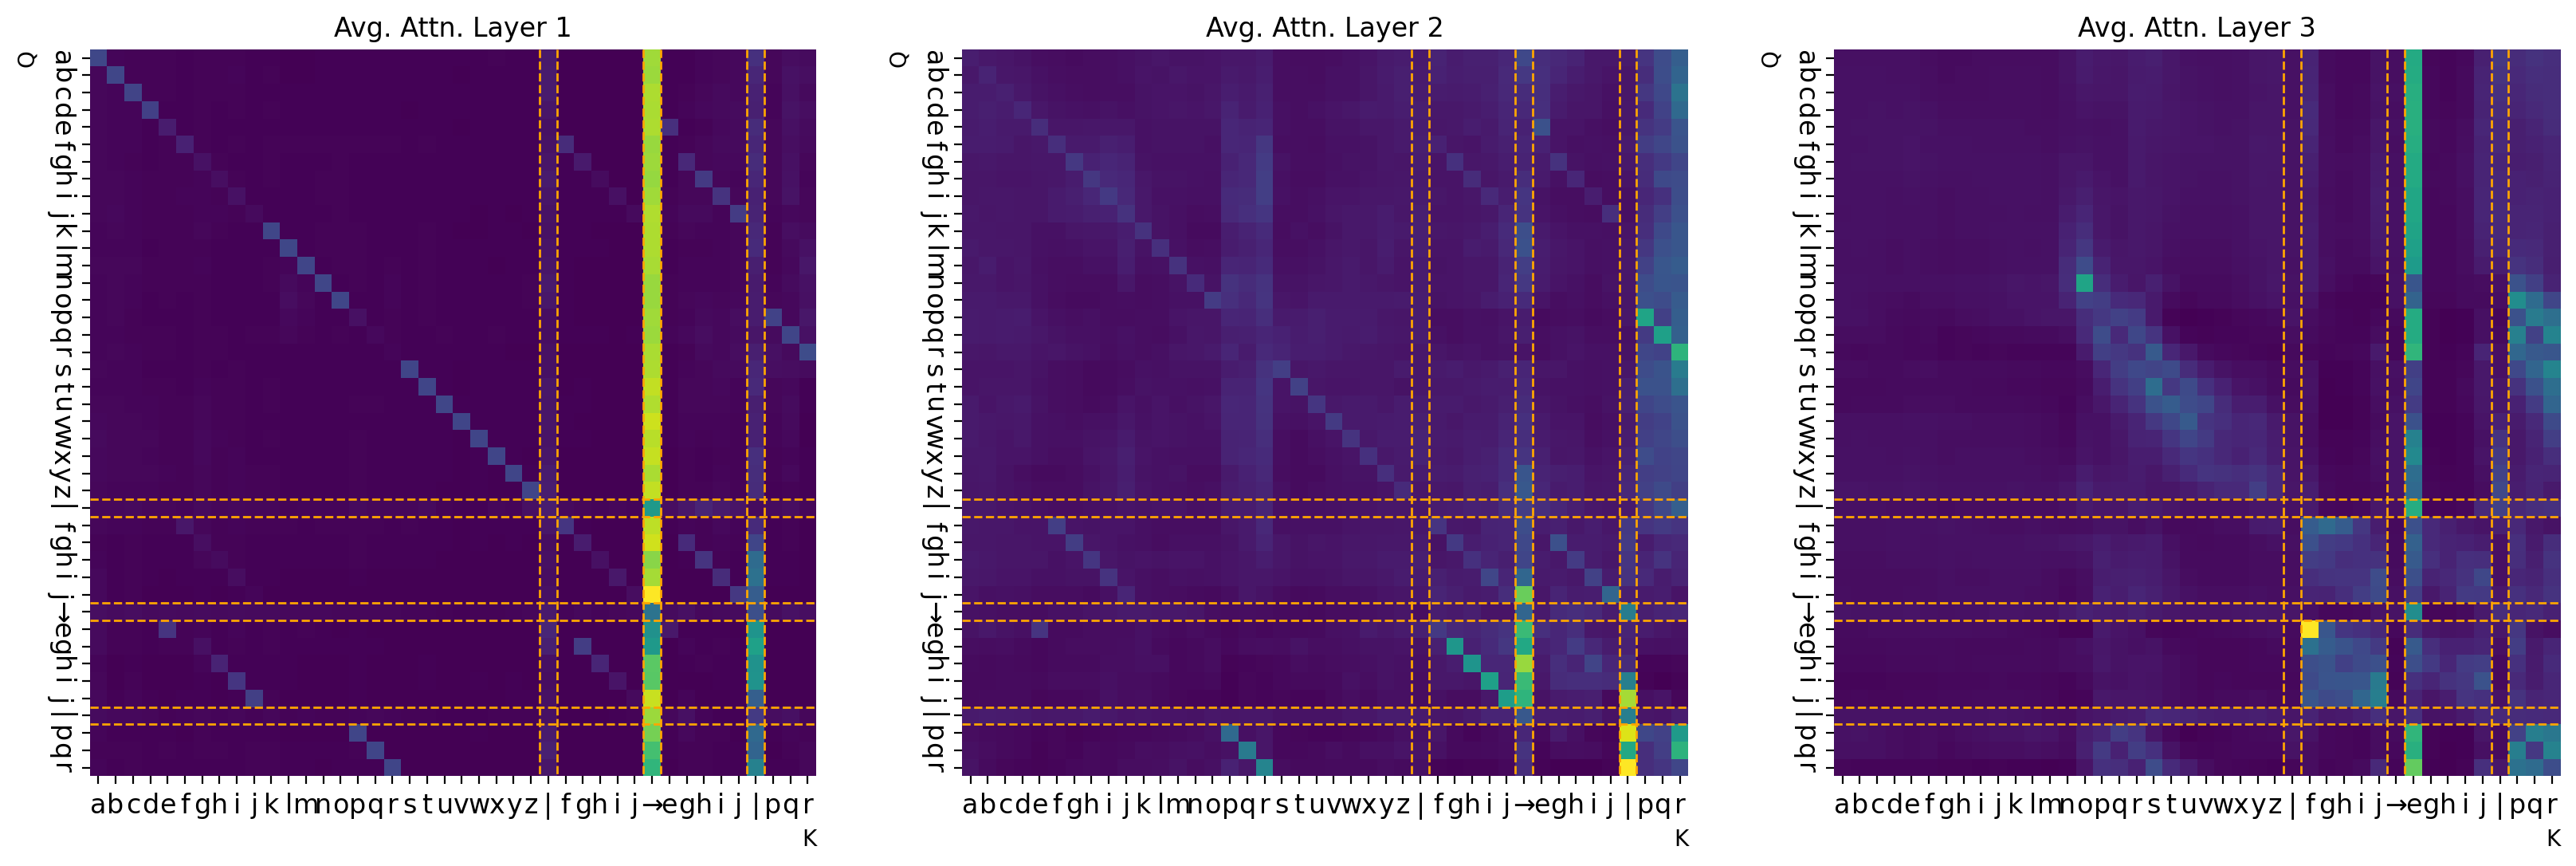

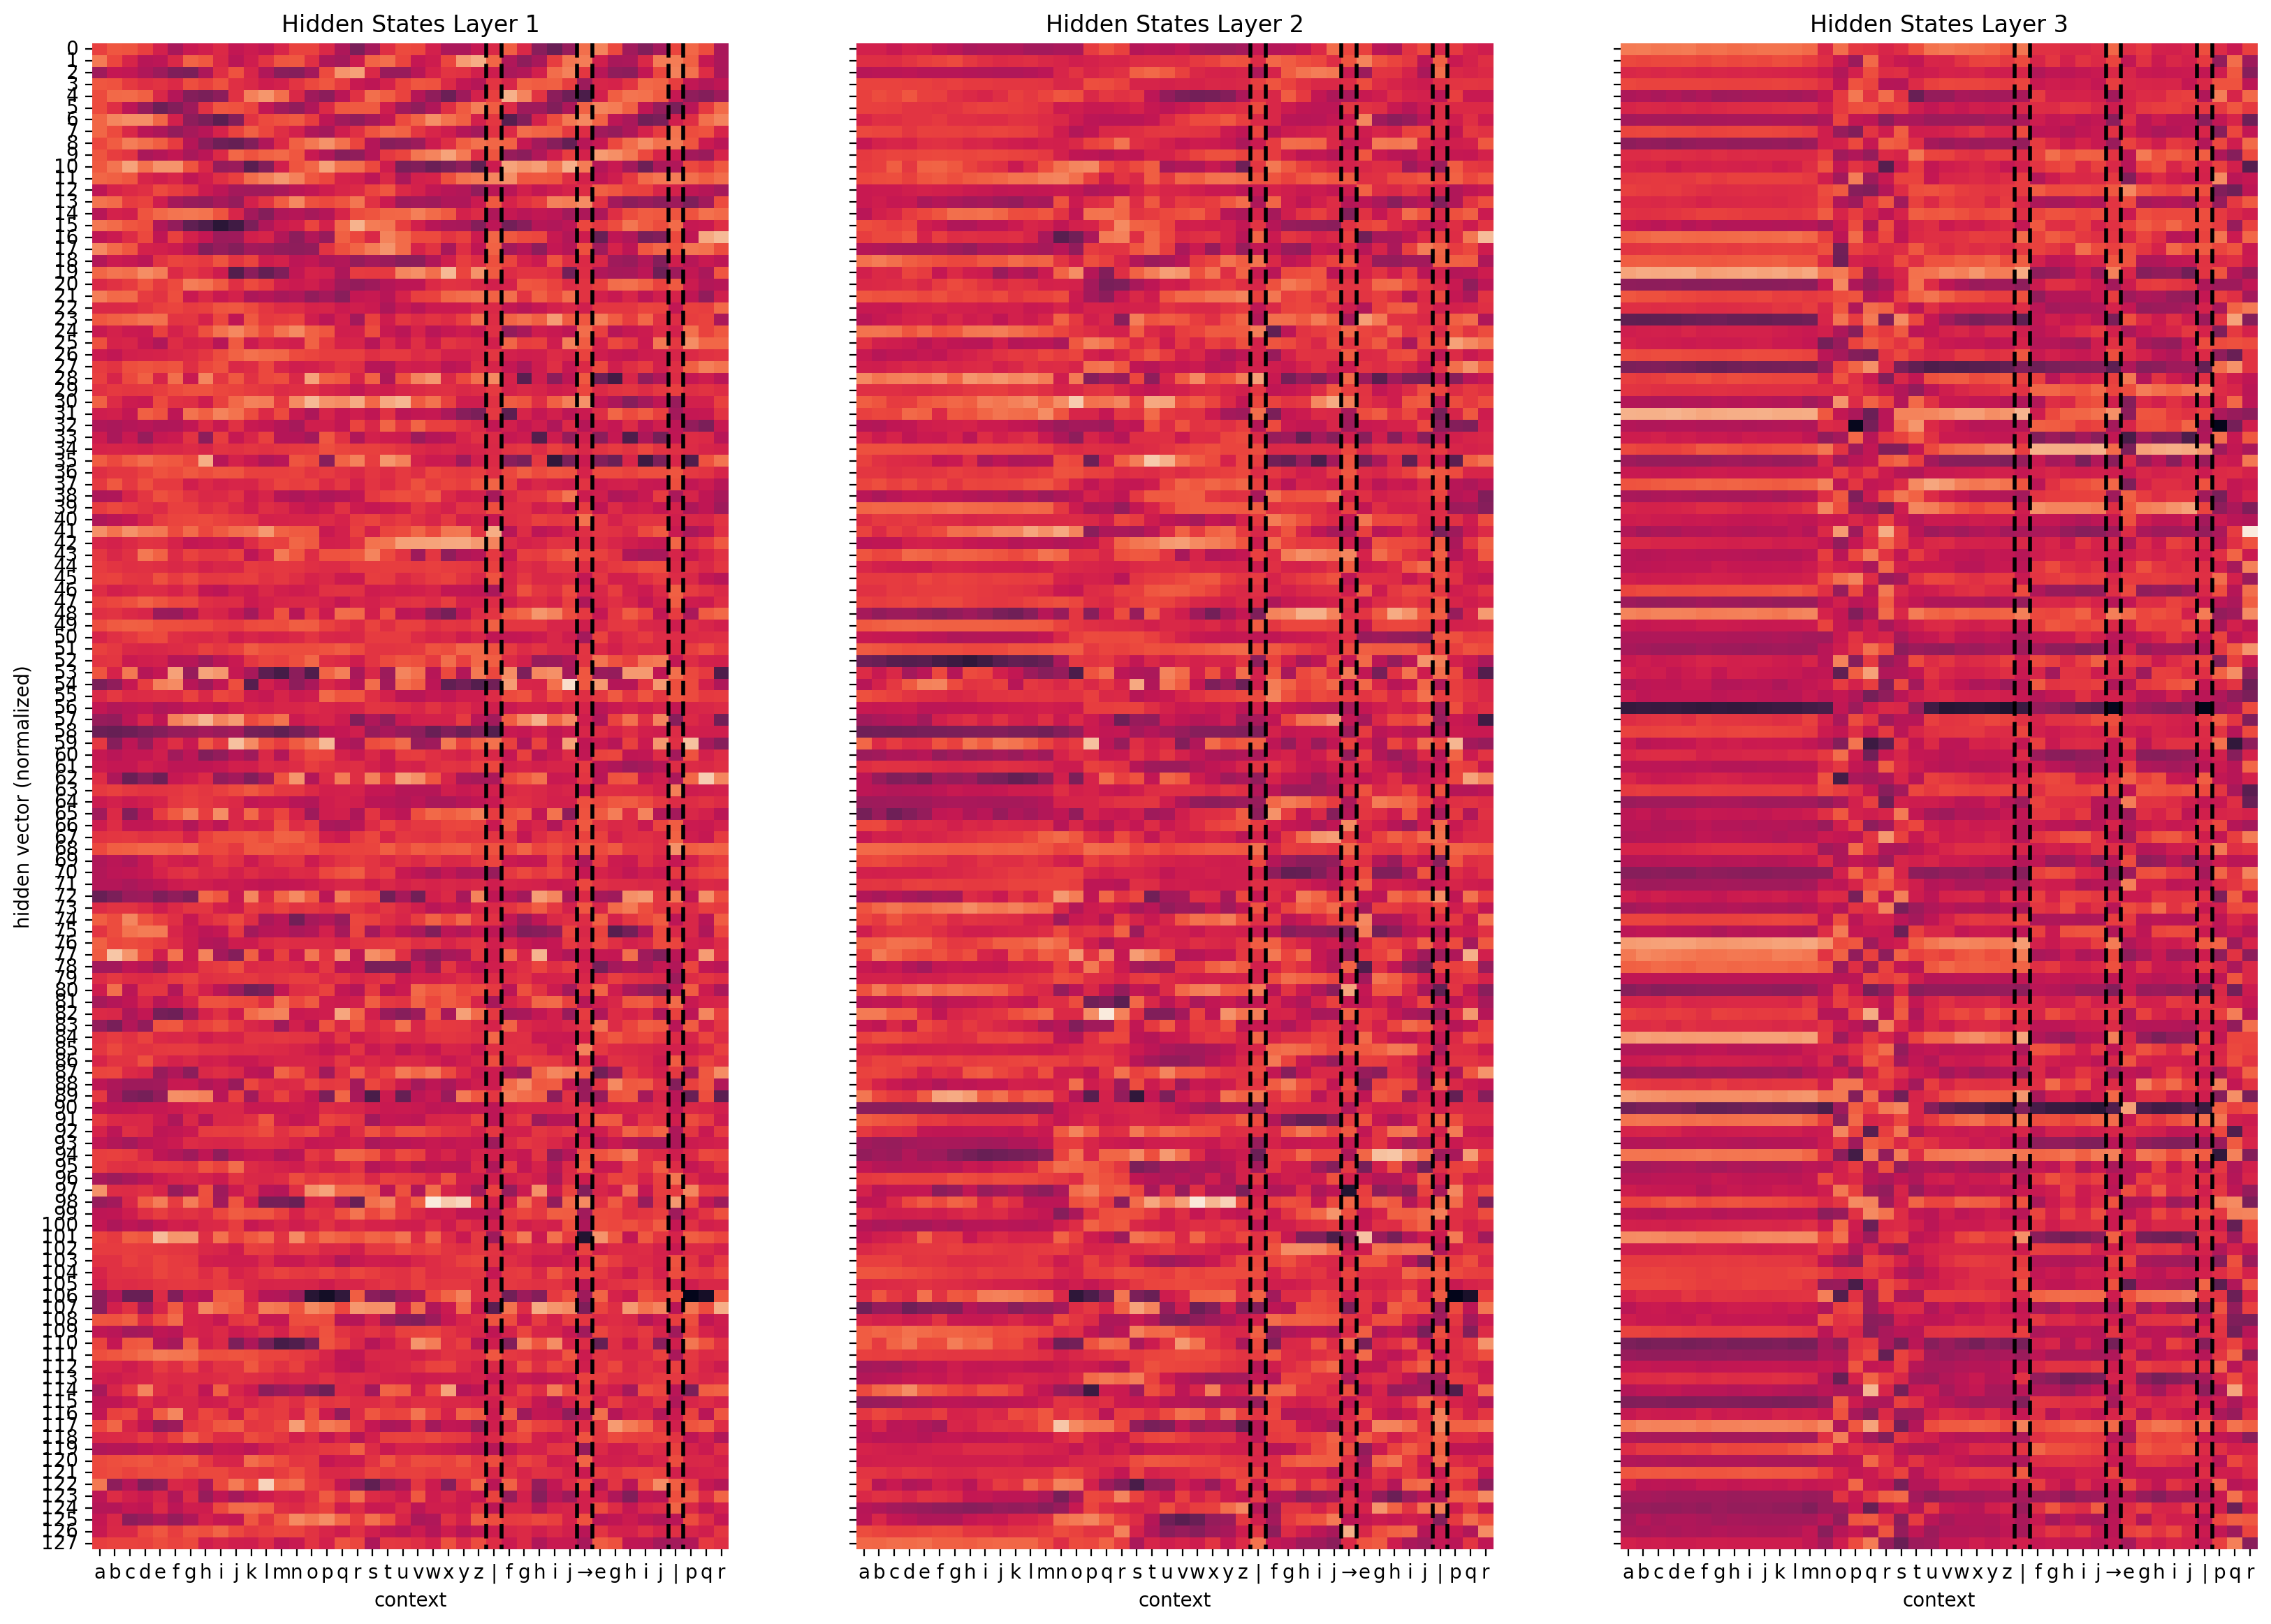

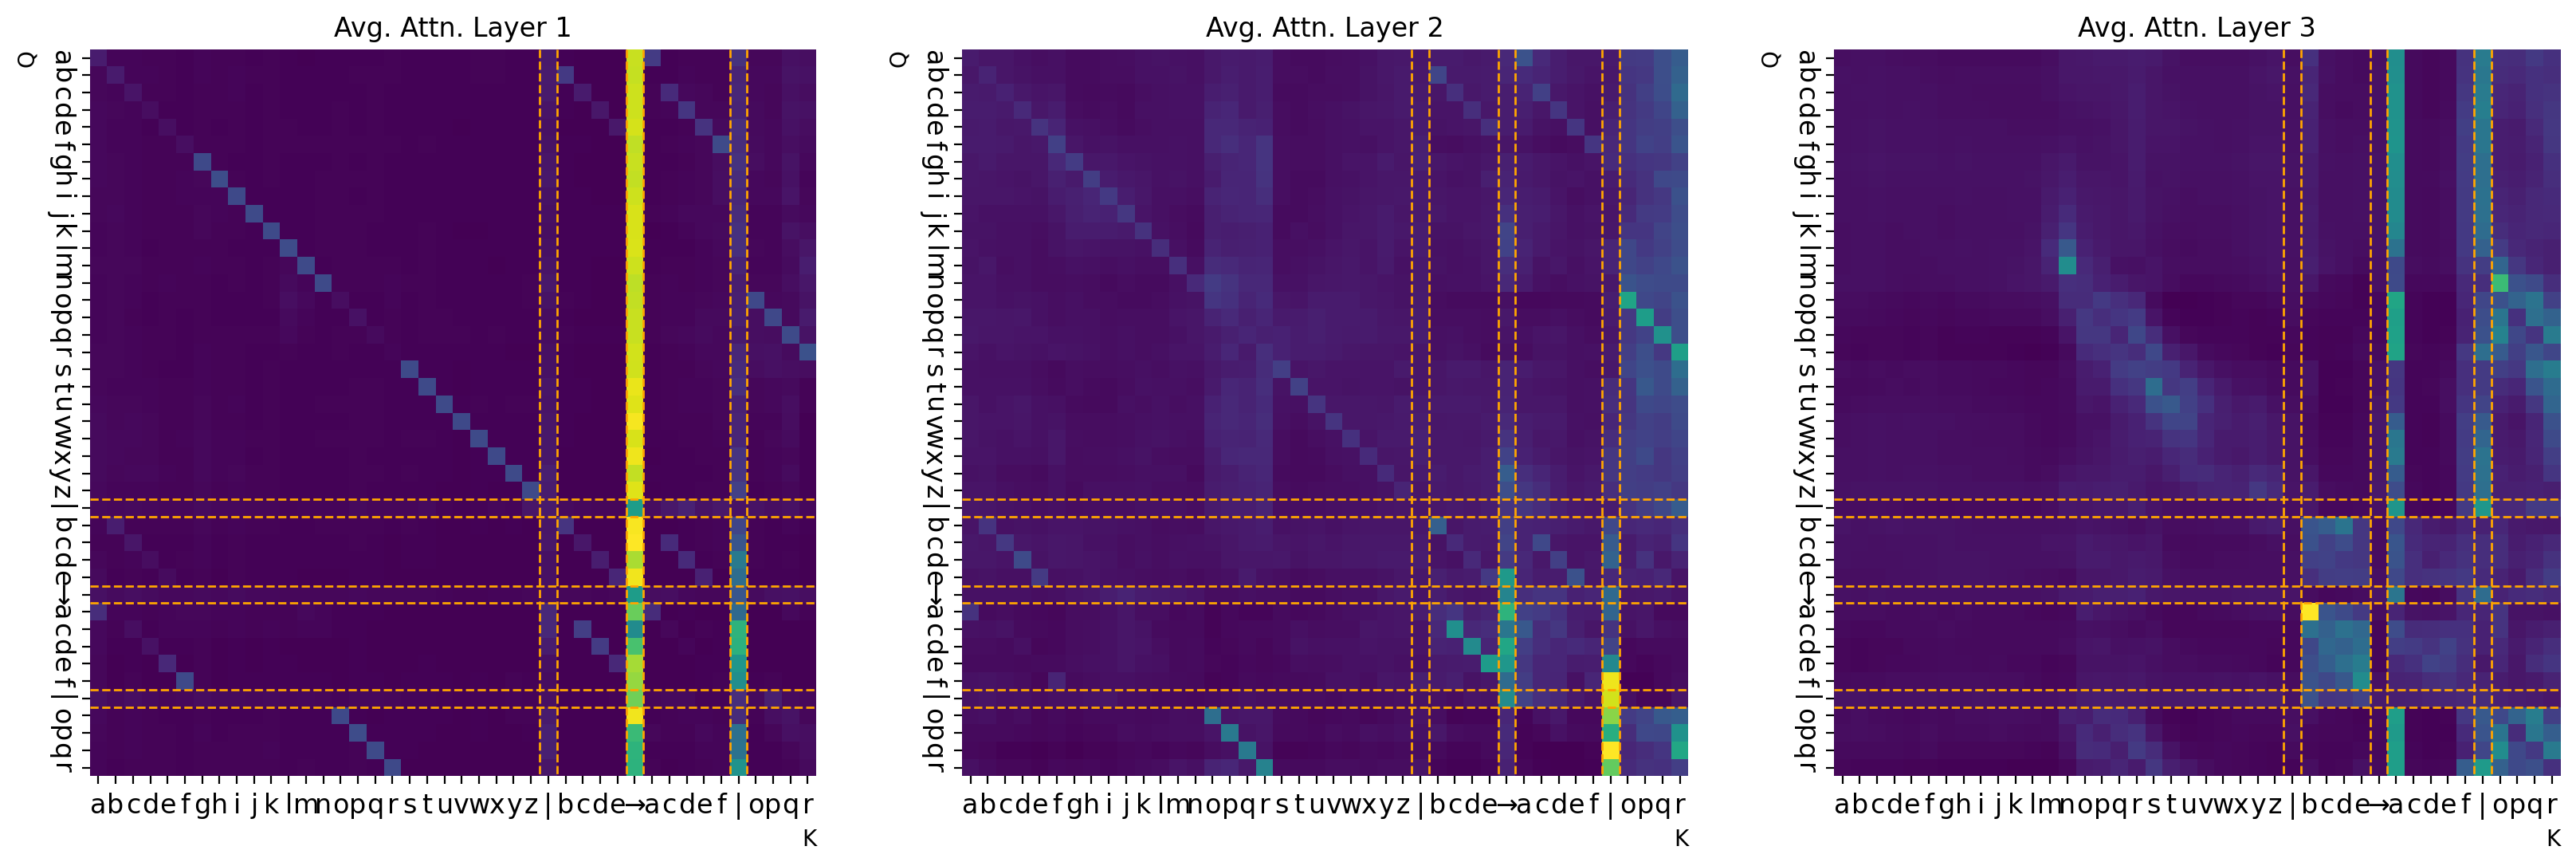

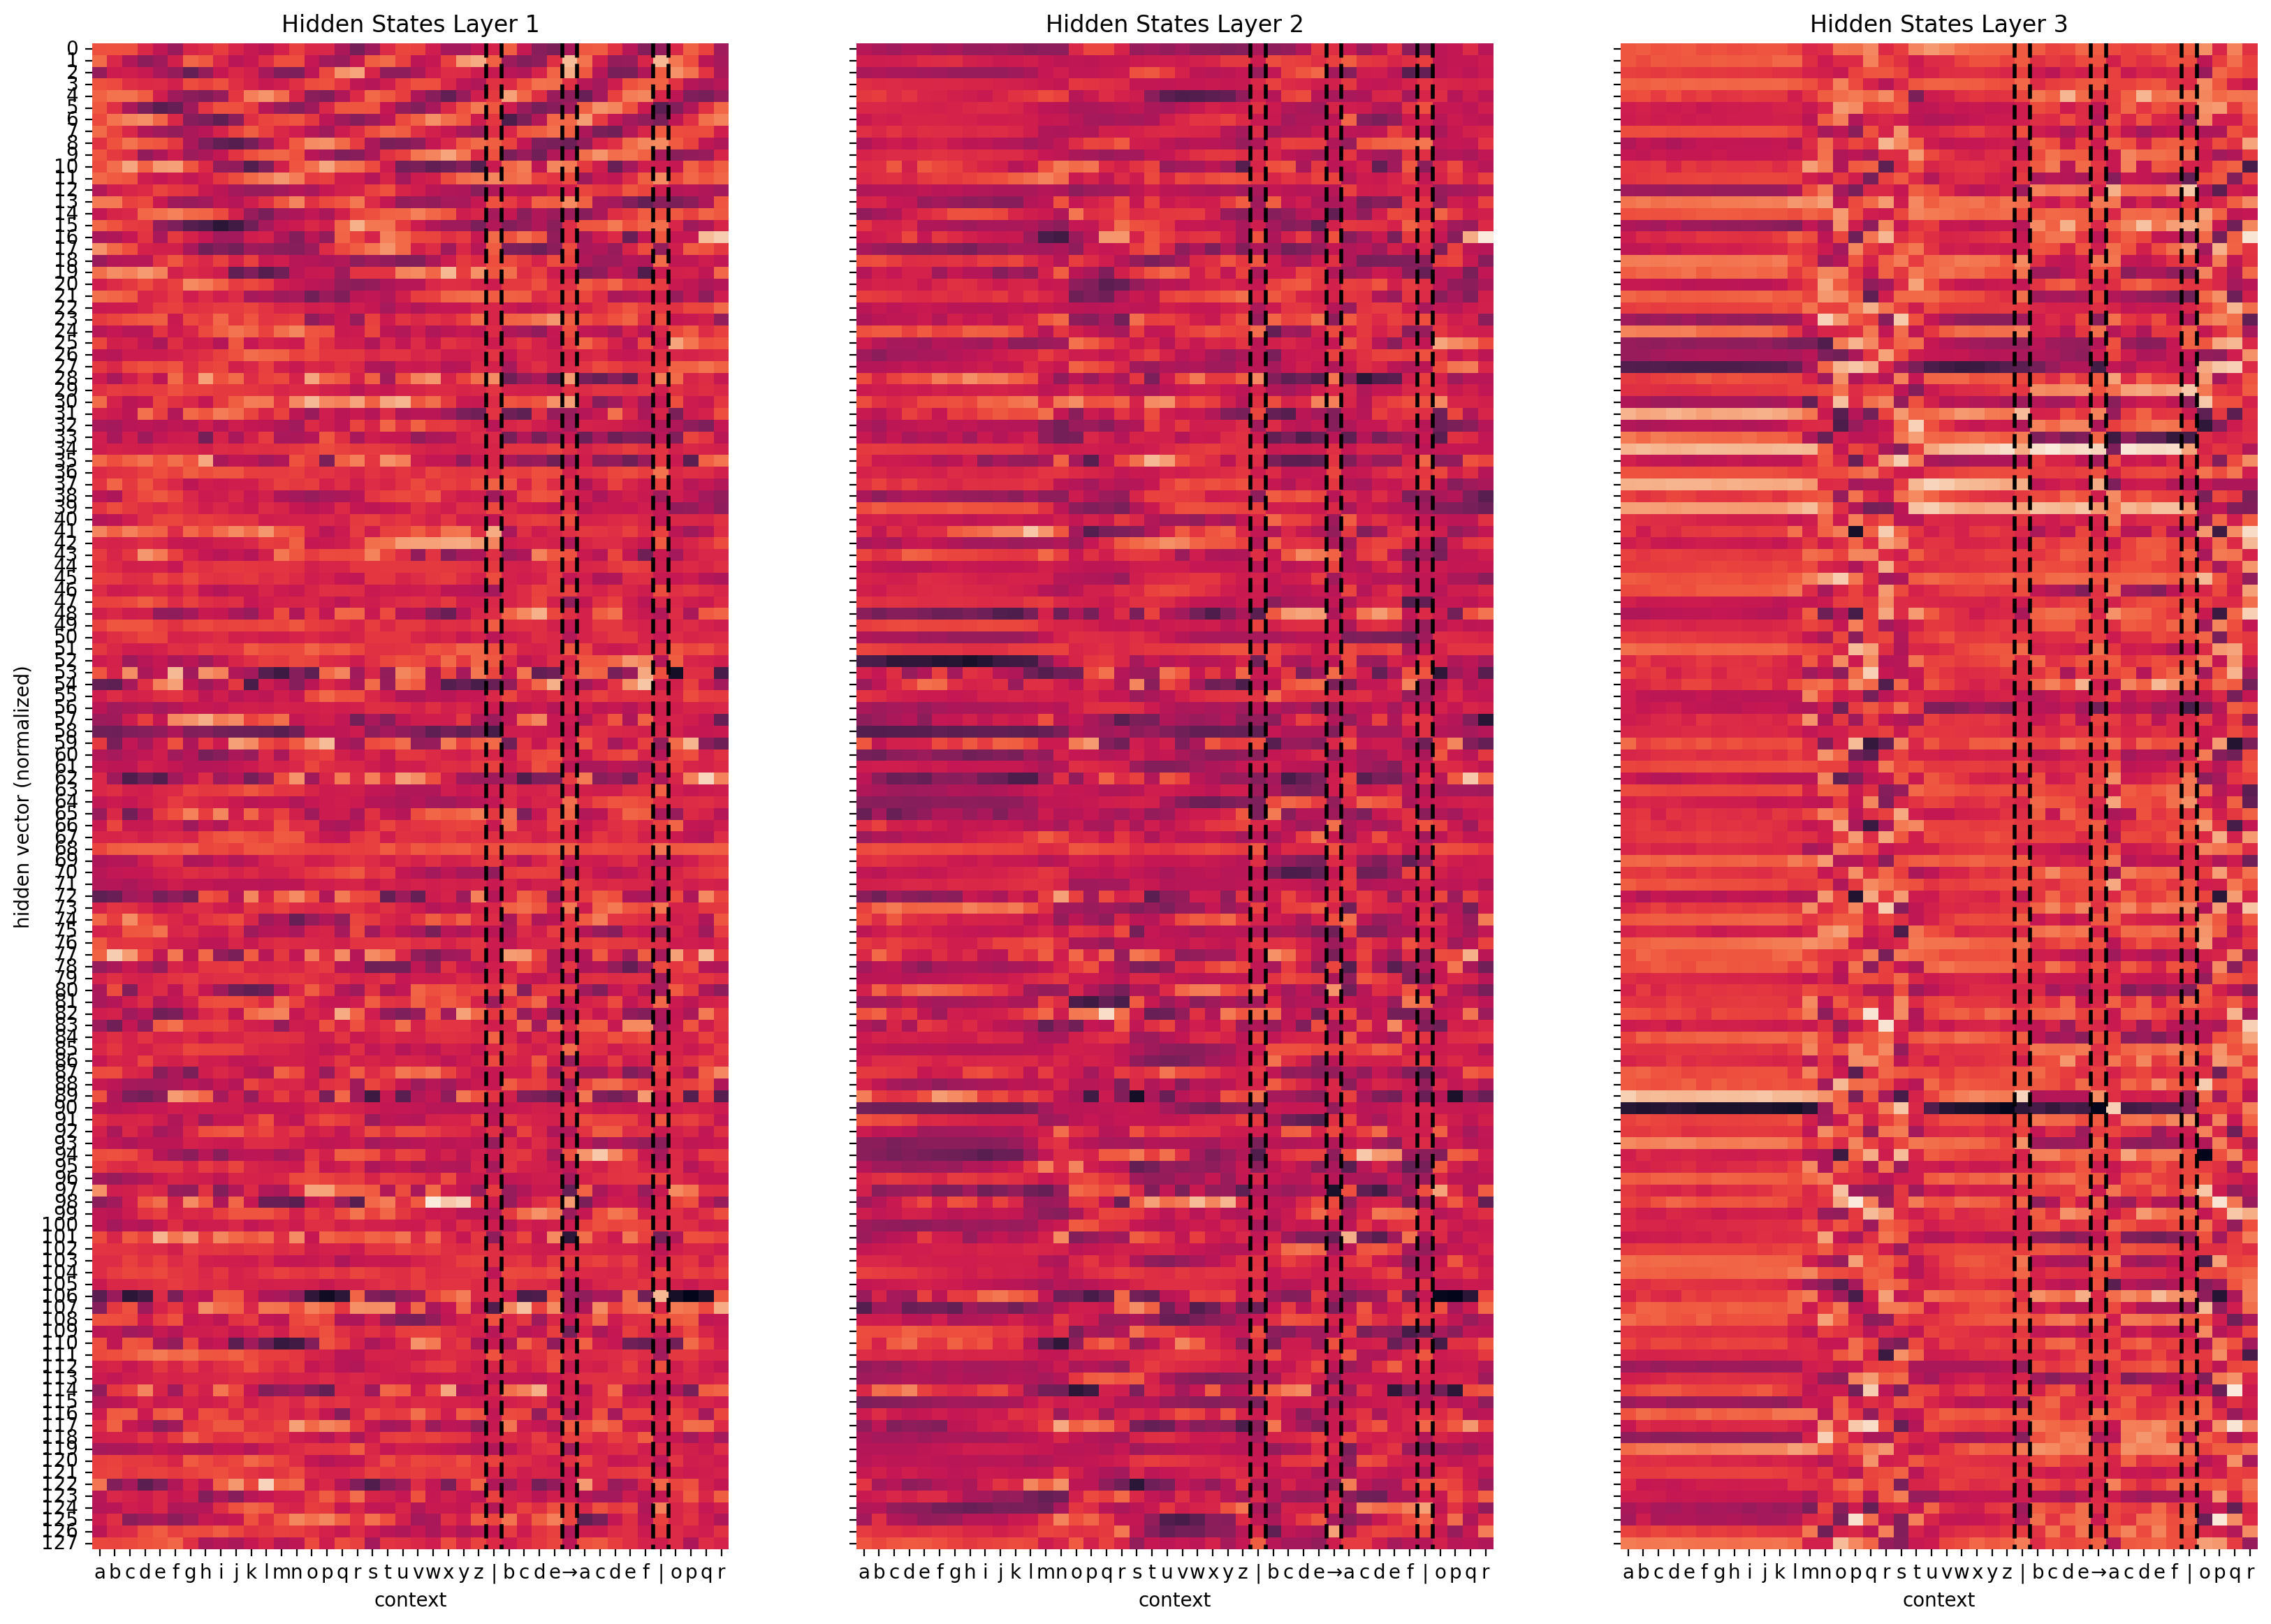

In [ ]:
for transformation in ["extend_sequence", "pred", "extend_pred"]:
    print("-" * 60)
    print(f"Analysing transformation '{transformation}'")
    print("-" * 60)
    dataloader.dataset.set_filter("transformation_alphabet", [" | ".join([transformation, " ".join(list(string.ascii_lowercase))])])
    
    # set seed for batch
    random.seed(10)
    batch = next(iter(dataloader))
    noncopy_ids = np.where(np.array(batch["copy"]) == False)
    idx = noncopy_ids[0][0]
    print("Task:")
    print(f'{batch["alphabet"][idx]} | {batch["study"][idx]} | {batch["problem"][idx]}\n')
    
    # run model on batch
    model_best.eval()
    with torch.no_grad():
        output = model_best(batch["yq_io_padded"], batch)

    # plot attention per layer and per head:
    plot_averaged_attention(extractor, batch, idx, cbar=False)
    plot_hidden_states(extractor, batch, idx, cbar=False)
    extractor.clear()


#### Hidden State Comparison

In [4]:
dataloader.dataset.set_filter("transformation_alphabet", [" | ".join(["pred", " ".join(list(string.ascii_lowercase))])])
    
# set seed for batch
random.seed(10)
batch = next(iter(dataloader))
noncopy_ids = np.where(np.array(batch["copy"]) == False)
idx = noncopy_ids[0][0]

with torch.no_grad():
    output = model_best(batch["yq_io_padded"], batch)

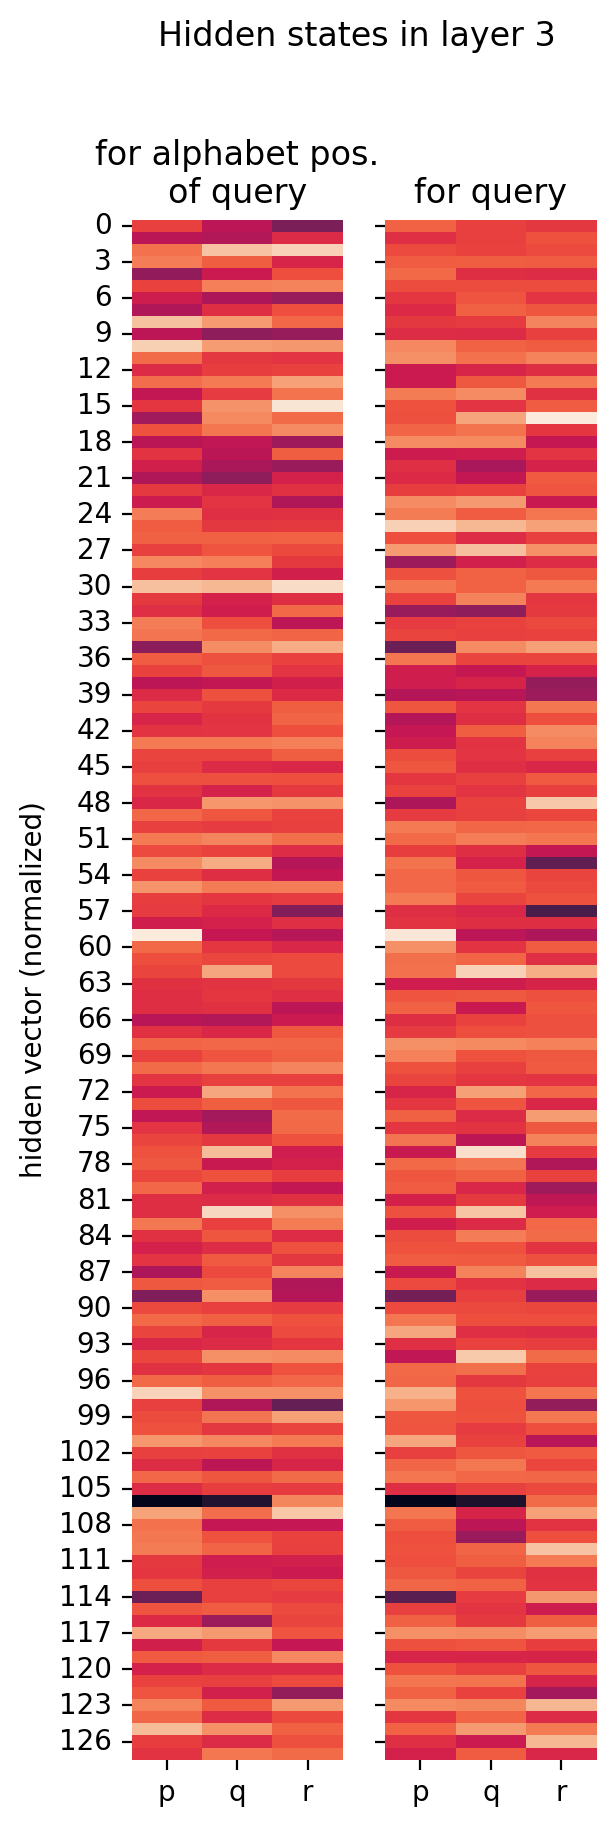

In [ ]:
alphabet_query_ids = [15]
query_in_ids = [39]
alphabet_query_ids = list(range(15,18))
query_in_ids = list(range(39,42))

# plot encoder representations:
fig, ax = plt.subplots(1, 2, sharey=True, figsize=(3, 10))
plt.suptitle("Hidden states in layer 3")
labels = au.format_context_labels(batch, idx)

for i, ids in enumerate([alphabet_query_ids, query_in_ids]):
    hidden_size = extractor.hidden_states[f'layer_{2}'][idx].shape[1]
    sns.heatmap(
        extractor.hidden_states[f'layer_{i}'][idx][ids].T, 
        ax=ax[i], 
        xticklabels=[lab for num, lab in enumerate(labels) if num in ids],
        cbar=False
    )
    if i==0:
        ax[i].set_title("for alphabet pos.\nof query")
        ax[i].set_ylabel("hidden vector (normalized)")
    else:
        ax[i].set_title("for query")
    ax[i].tick_params(axis='x', labelrotation=0)

In [72]:
labs = [lab for num, lab in enumerate(labels) if num in ids]
for lab, alph, query in zip(labs, alphabet_query_ids, query_in_ids):
    alph_hidden = extractor.hidden_states["layer_2"][idx][alph]
    query_hidden = extractor.hidden_states["layer_2"][idx][query]

    cos_sim = torch.nn.functional.cosine_similarity(alph_hidden, query_hidden, dim=0)
    print(f"Dot product between alph and query for letter {lab}: {cos_sim}")


Dot product between alph and query for letter p: 0.9796414375305176
Dot product between alph and query for letter q: 0.9496299028396606
Dot product between alph and query for letter r: 0.837524950504303


### Attention per Head

In [7]:
dataloader.dataset.transformation_types

['rr_sort',
 'extend_sequence',
 'extend_pred',
 'shift',
 'replicate',
 'reverse',
 'fix_extend',
 'rr_interleave',
 'sort_group',
 'fix_alphabetic_seq',
 'fix_interleave',
 'remove_redundant',
 'rr_succ',
 'pred',
 'extend_extend_succ',
 'fix_pred_succ',
 'succ',
 'extend_group',
 'sort']

In [6]:
trans = "pred"
dataloader.dataset.set_filter("transformation_alphabet", [" | ".join([trans, " ".join(list(string.ascii_lowercase))])])

# set seed for batch
random.seed(10)
batch = next(iter(dataloader))
noncopy_ids = np.where(np.array(batch["copy"]) == False)

Task:
a b c d e f g h i j k l m n o p q r s t u v w x y z | f g h i j > e g h i j | p q r > o q r



C:\Users\13579681\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\transformer.py:505: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


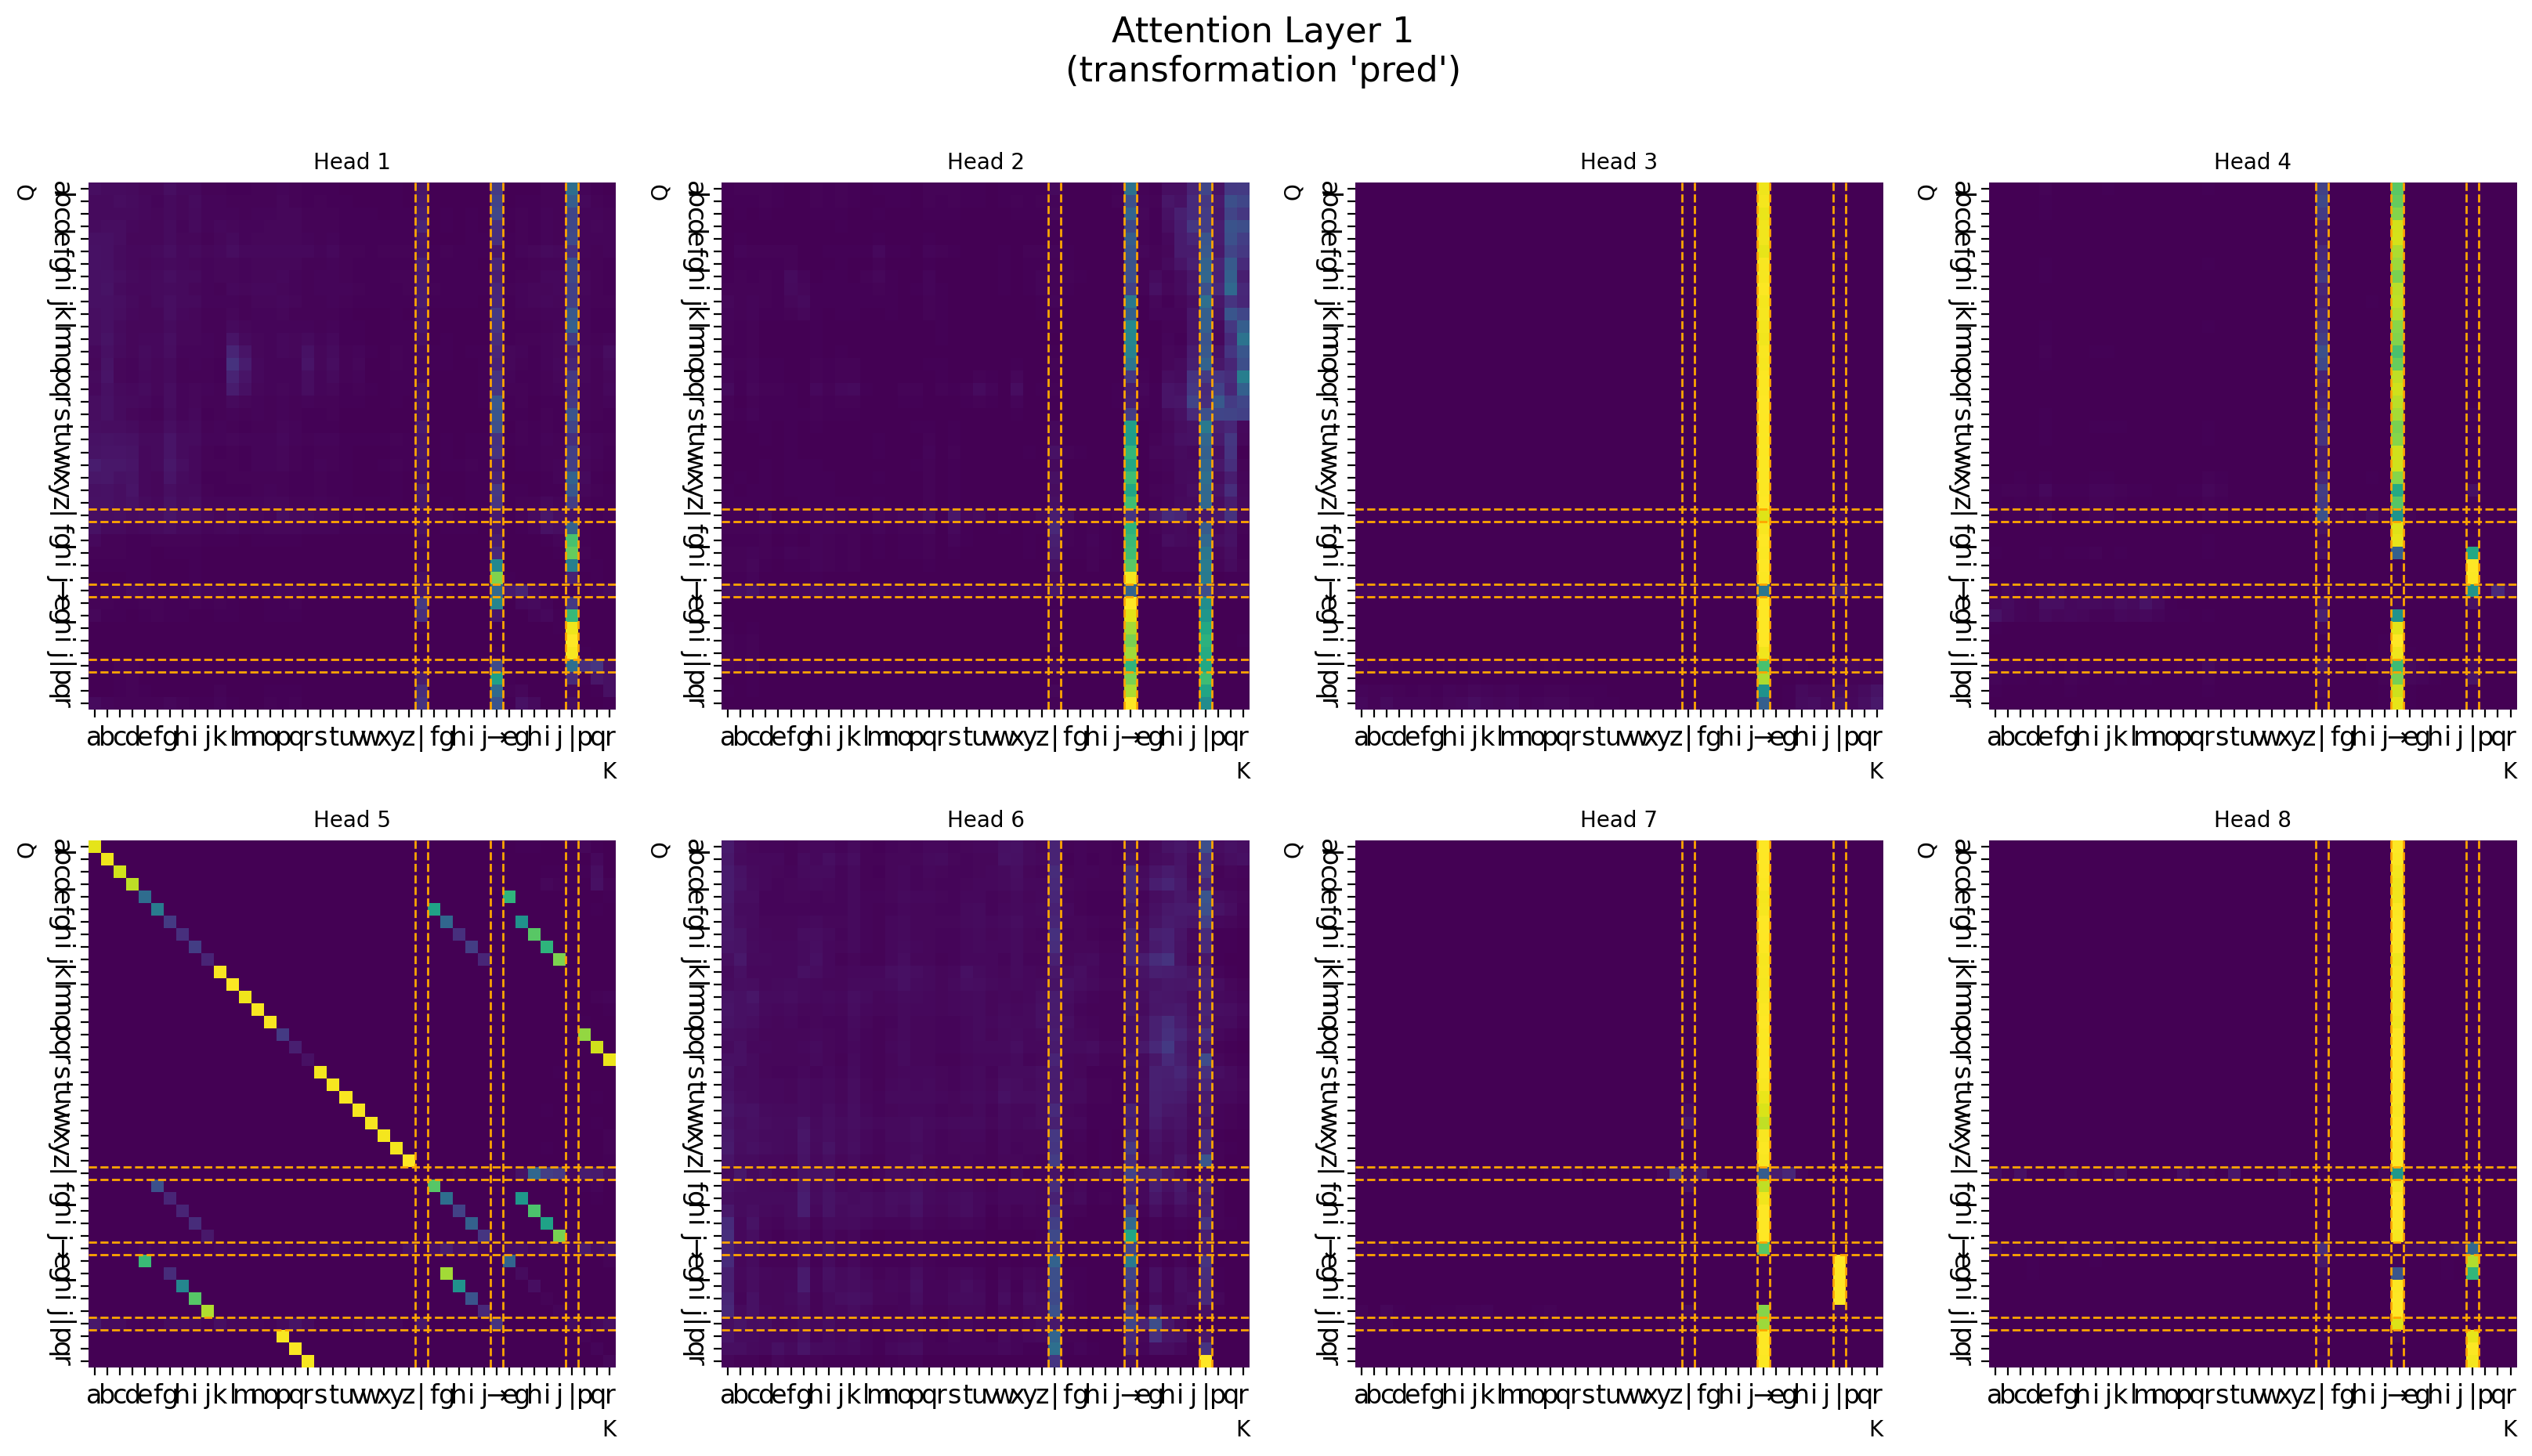

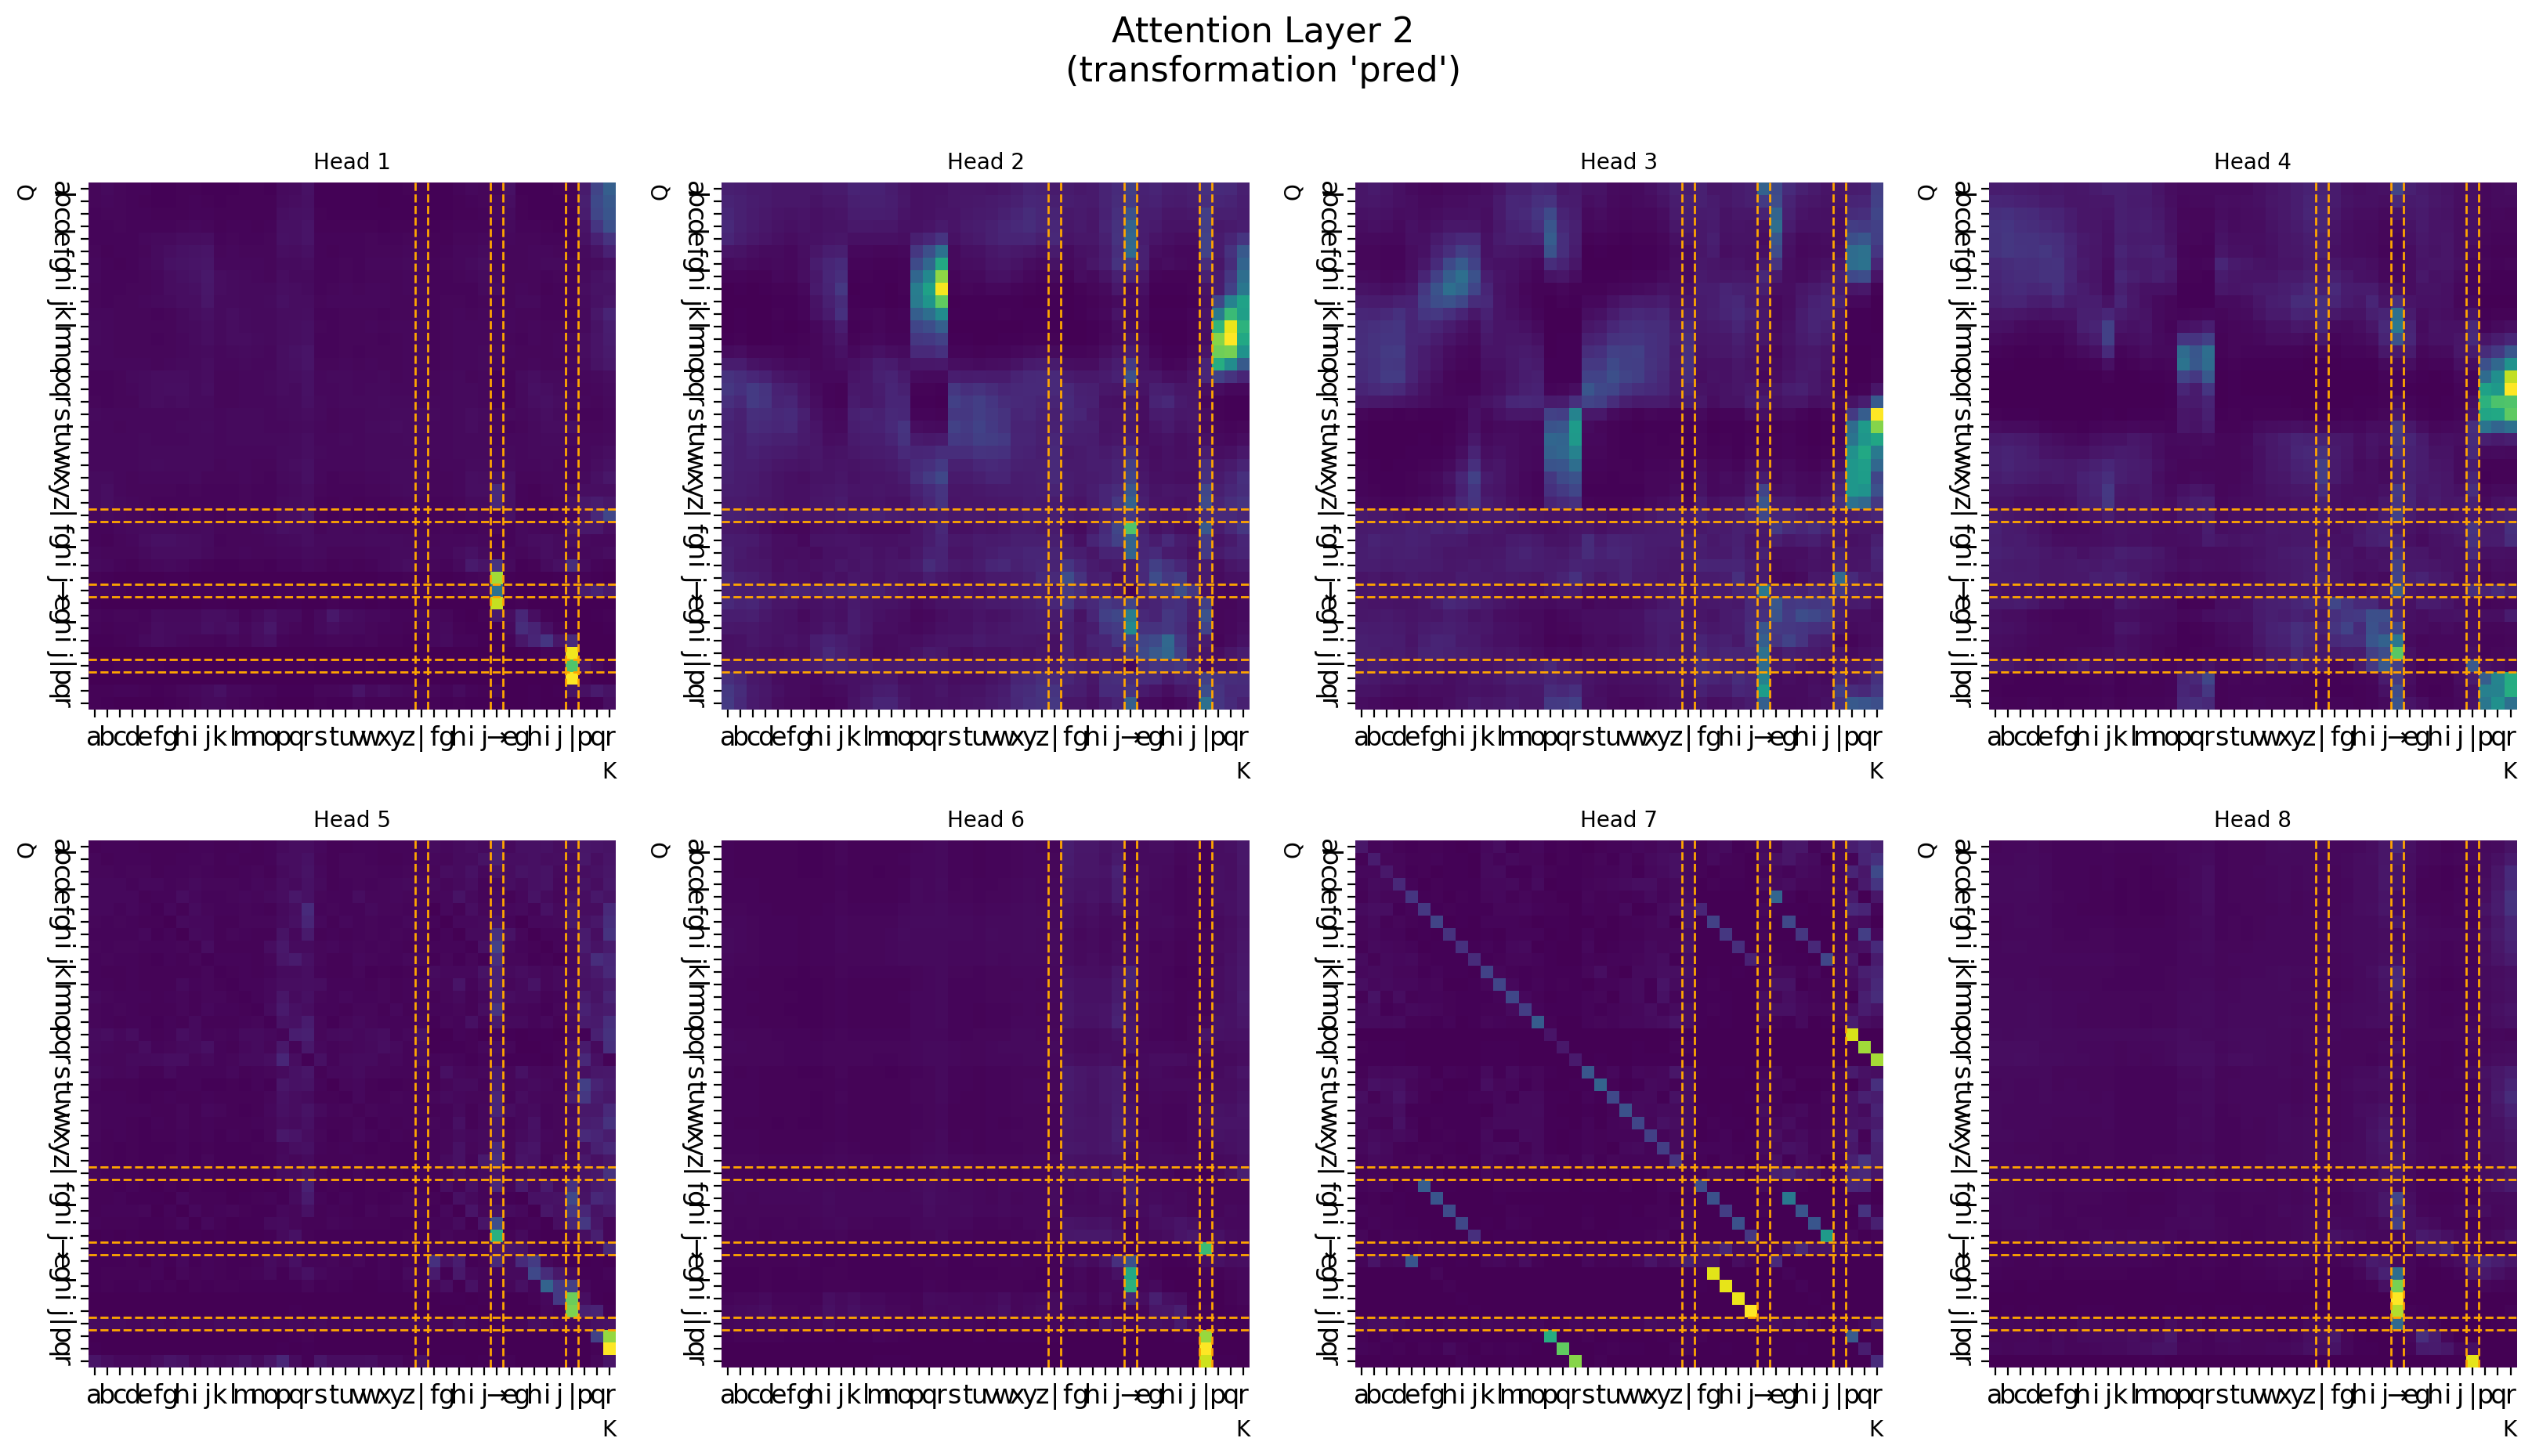

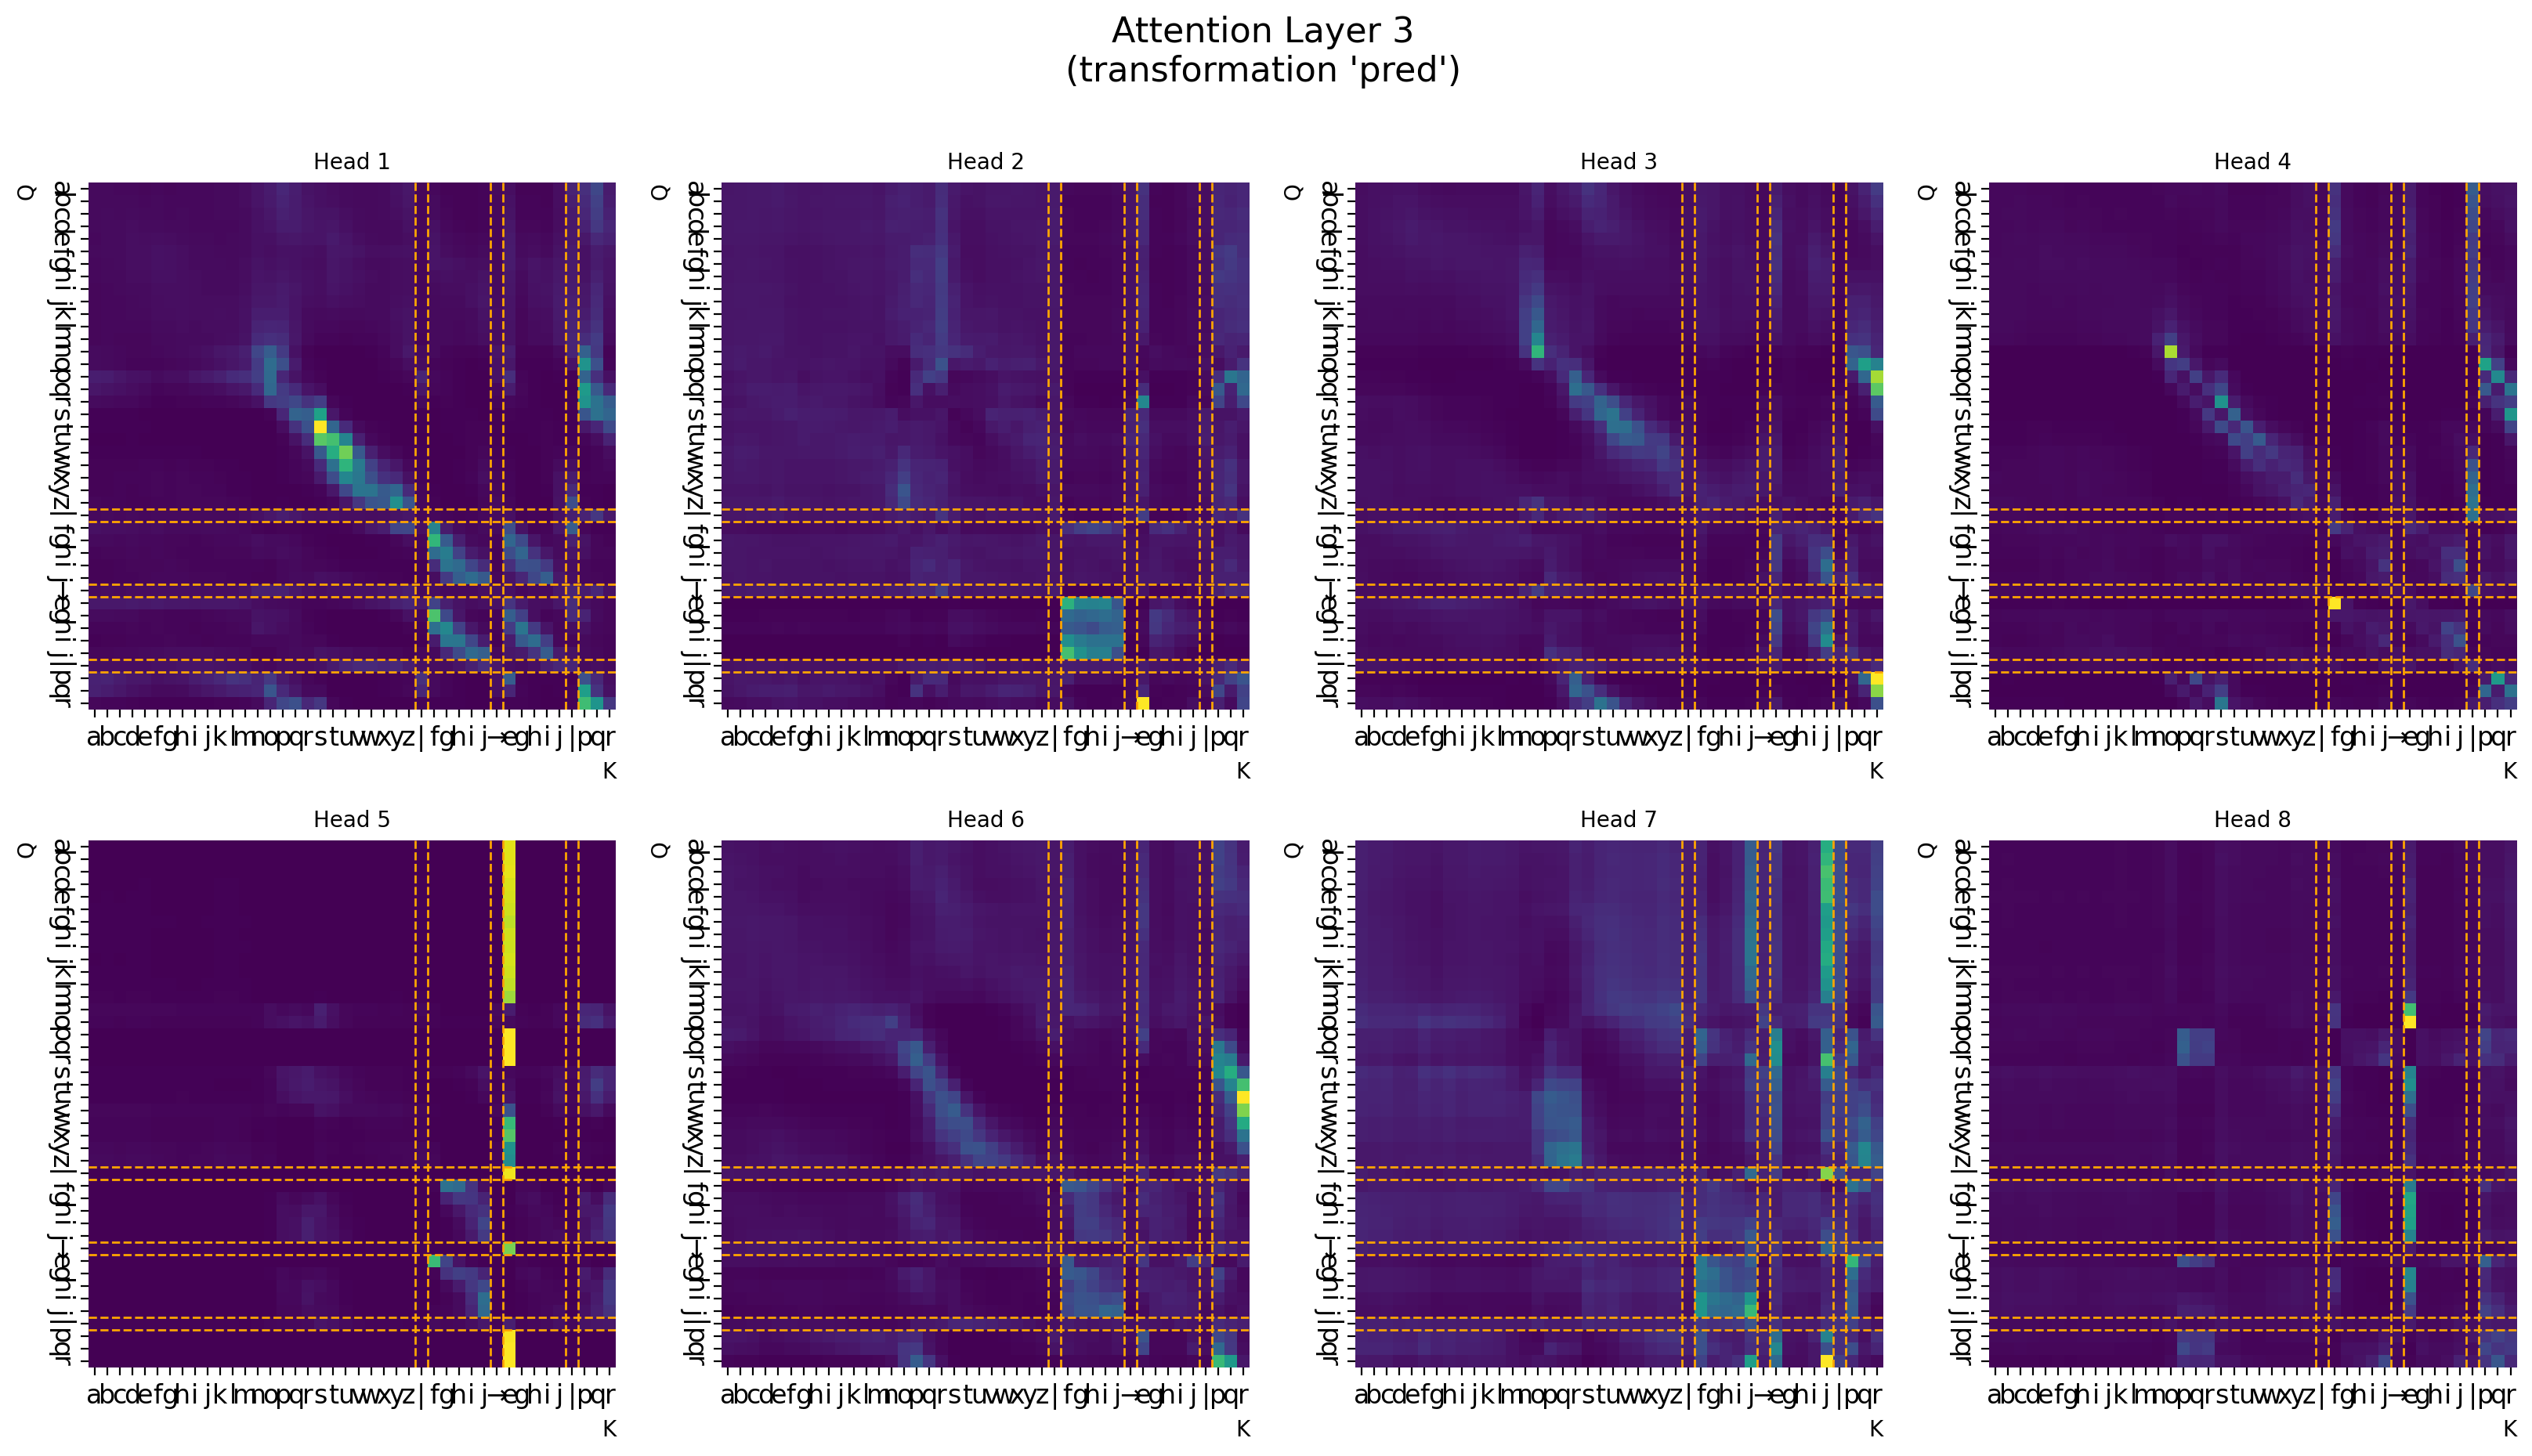

In [7]:
idx = noncopy_ids[0][0]
print("Task:")
print(f'{batch["alphabet"][idx]} | {batch["study"][idx]} | {batch["problem"][idx]}\n')

# run model on batch
model_best.eval()
with torch.no_grad():
    output = model_best(batch["yq_io_padded"], batch)

plot_headwise_attention(extractor, batch, idx, transformation=trans, cbar=False)

### Cross-attention analysis

In [7]:
transformation = "succ"
dataloader.dataset.set_filter("transformation_alphabet", [" | ".join([transformation, " ".join(list(string.ascii_lowercase))])])
    
# set seed for batch
random.seed(10)
batch = next(iter(dataloader))
noncopy_ids = np.where(np.array(batch["copy"]) == False)
print(noncopy_ids)


# run model on batch
model_best.eval()
with torch.no_grad():
    output = model_best(batch["yq_io_padded"], batch)

(array([0, 2, 4, 6, 8, 9]),)


C:\Users\13579681\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\transformer.py:505: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


In [16]:
idx=6
print("Task:")
print(f'{batch["alphabet"][idx]} | {batch["study"][idx]} | {batch["problem"][idx]}\n')

Task:
a b c d e f g h i j k l m n o p q r s t u v w x y z | u v w x > u v w y | g h i j k l > g h i j k m



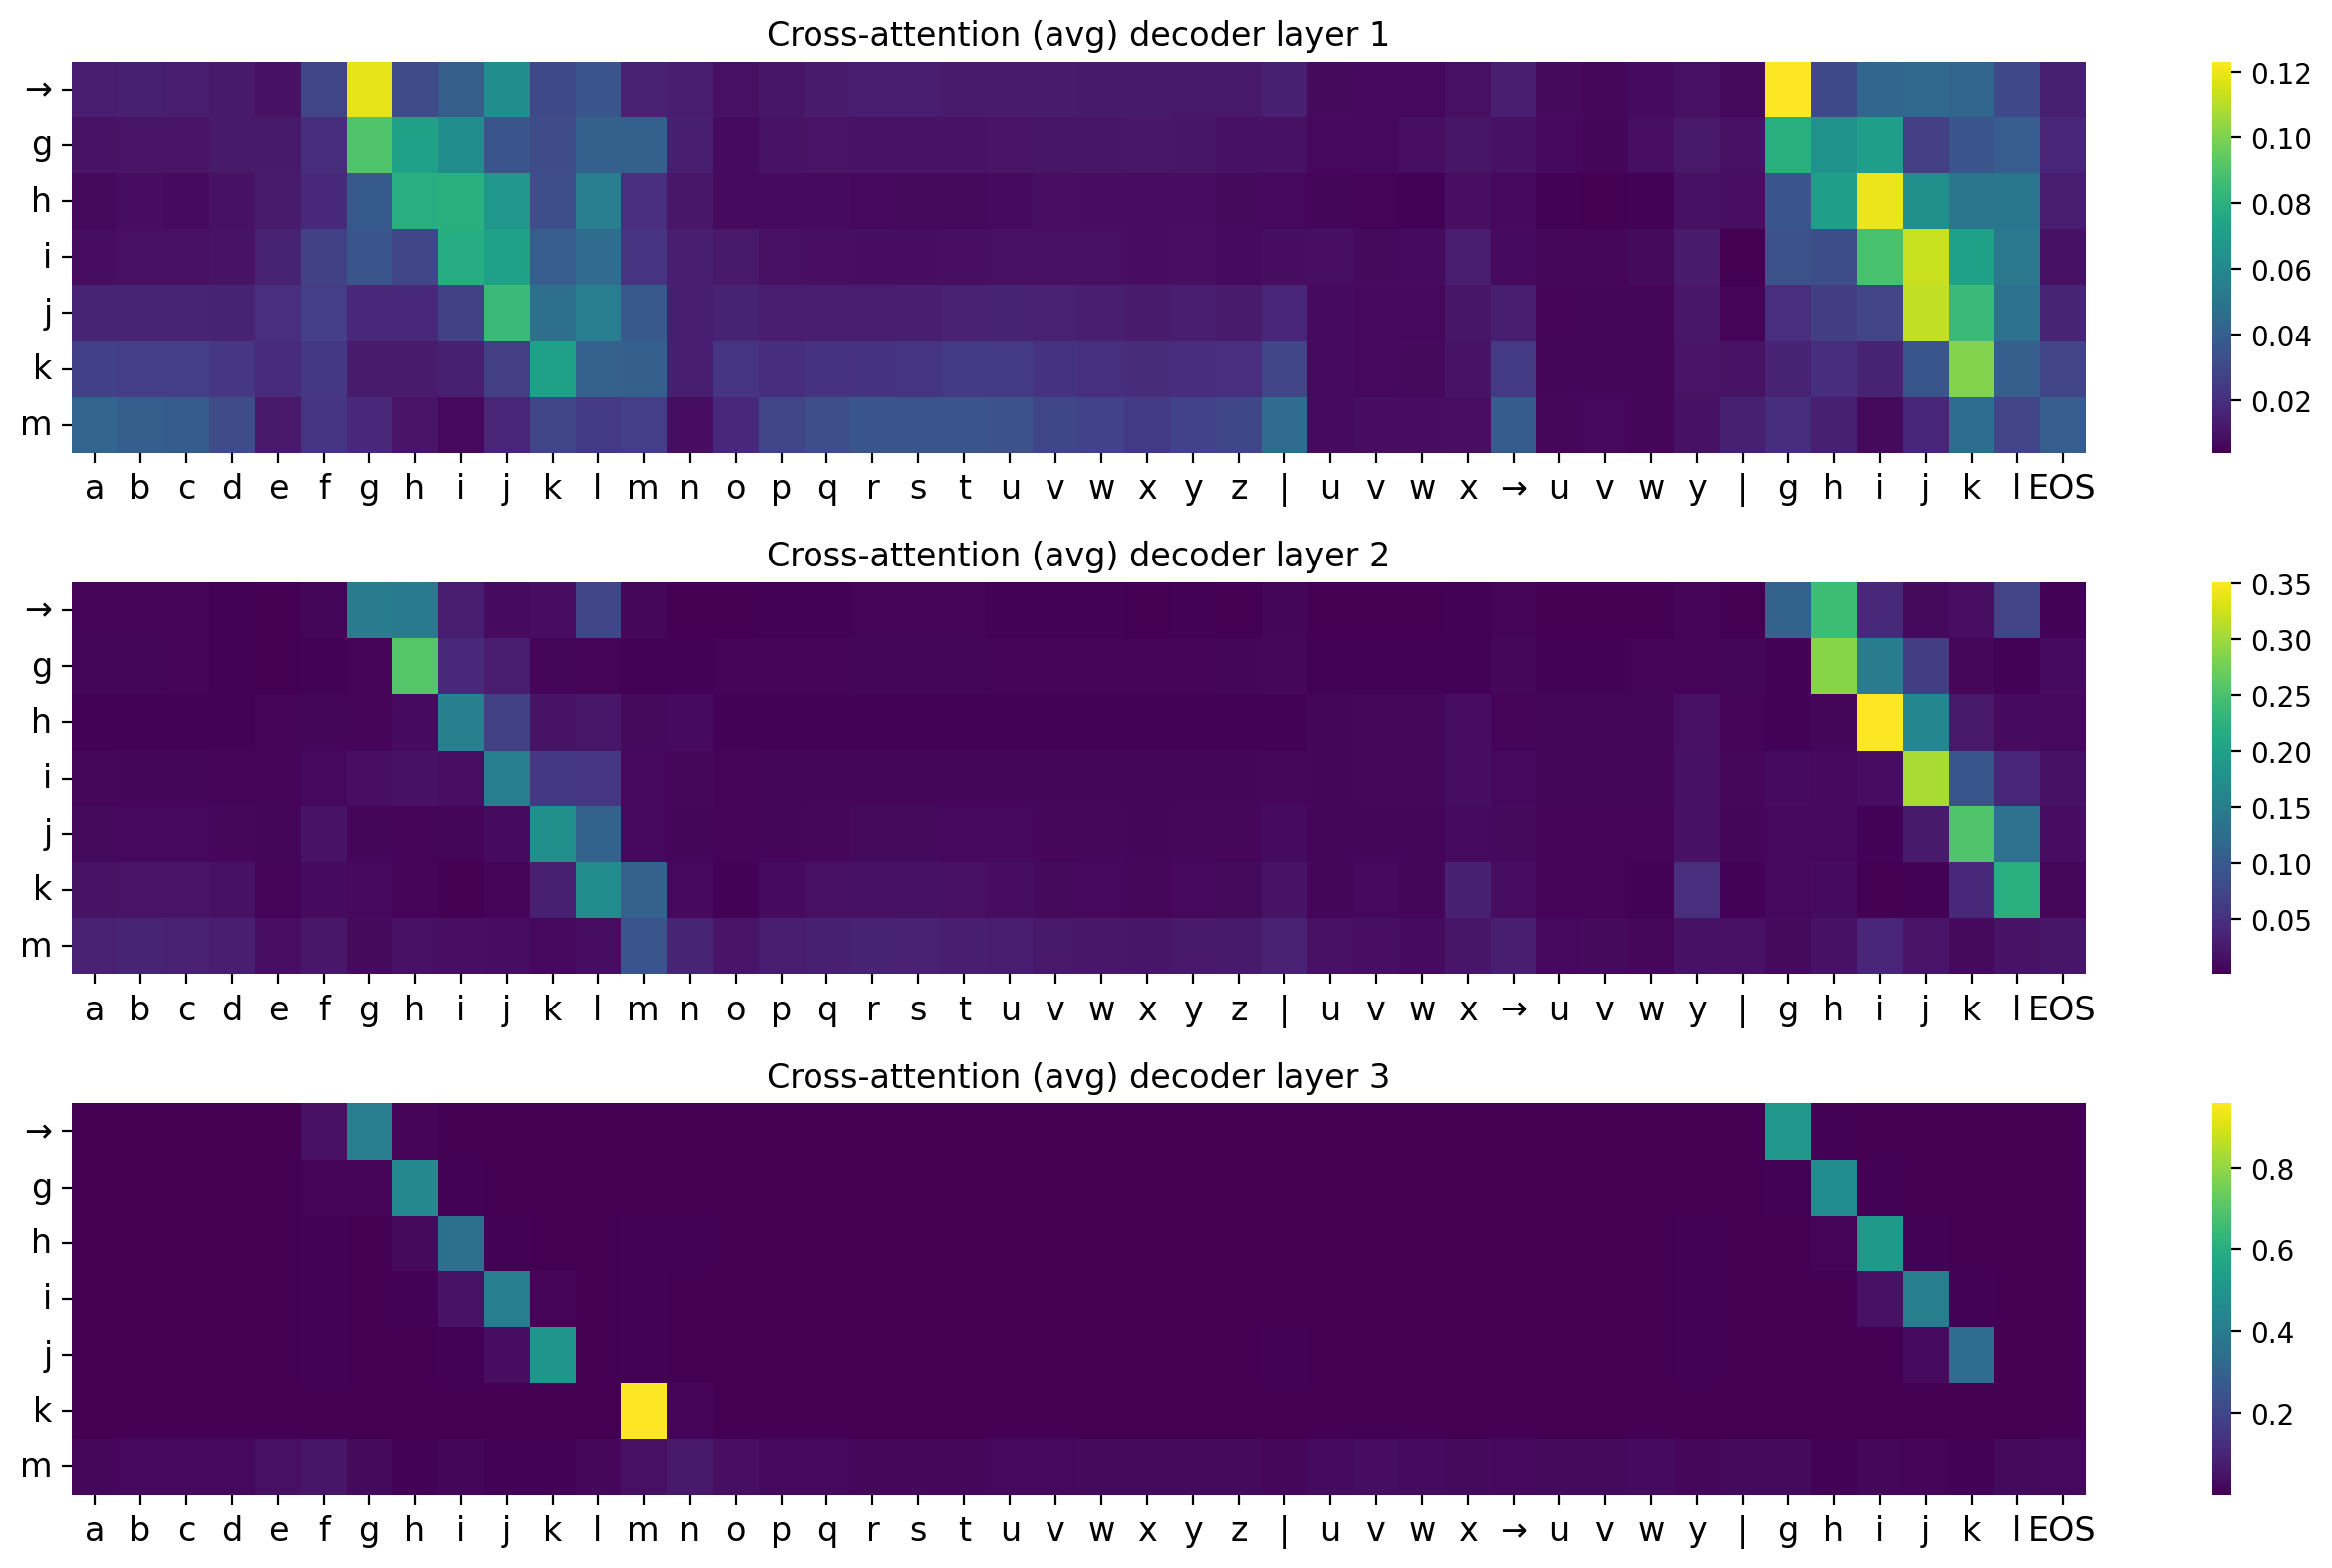

In [17]:

decoder_lang = dataloader.dataset.langs["output"]
decoder_labels = decoder_lang.tensor_to_symbols(batch["yq_io_padded"][idx])
decoder_labels[0] = "→"
encoder_labels = au.format_context_labels(batch, idx) + ["EOS"]
out_len = len(batch["yq"][idx]) + 1

fig, ax = plt.subplots(3, 1, figsize=(len(encoder_labels)*0.3, out_len +1))
for layer in range(3):
    cross_attn = extractor.decoder_attention[f"layer_{layer}"][idx]
    cross_attn_avg = cross_attn.mean(dim=0)
    sns.heatmap(
        cross_attn_avg[:out_len,:len(encoder_labels)], 
        ax=ax[layer], 
        cmap="viridis", 
        xticklabels=encoder_labels, 
        yticklabels=decoder_labels[:out_len]
    )
    ax[layer].set_xticklabels(ax[layer].get_xticklabels(), rotation=0, ha='center', fontsize=12)
    ax[layer].set_yticklabels(ax[layer].get_yticklabels(), rotation=0, va='center', fontsize=12)
    ax[layer].set_title(f"Cross-attention (avg) decoder layer {layer+1}")
fig.tight_layout()
plt.show()